# N.E.U.R.O.N. (Neuroimaging and Event-based Unified Risk Outcomes Network)
## Forecasting the Cognitive Clock: Survival Modeling for Alzheimer's Progression

### Rice University · Data Science Capstone · Spring 2026

**Team:** Nathon Chavez, Omar Dajani, Eliza Iqbal, Savannah Nix, Fabrizio Pacheco, Evie Roth, Shichen Tang

**Sponsor Mentor:** Cindy Zhang  
**PhD Mentor:** Antonio Mendoza Gonzales  
**Faculty Mentor:** Xinjie Lan

---

## Overview

This notebook implements a multimodal survival analysis pipeline to predict Alzheimer's disease
progression using longitudinal clinical data from the Alzheimer's Disease Neuroimaging Initiative (ADNI).
Rather than framing progression as a binary classification problem, we model **time-to-event** outcomes
directly using survival analysis methods — preserving the censoring structure of the data and producing
interpretable risk rankings over continuous time.

**Two cohorts are modeled:**
- **MCI → AD** (primary): subjects diagnosed with Mild Cognitive Impairment at baseline
- **CN → MCI or AD** (secondary): cognitively normal subjects at baseline

**Four model families are trained and compared:**

| Model | Family | Key Characteristic |
|-------|--------|--------------------|
| Cox PH (elastic net) | Linear | Interpretable log-hazard ratios; L1/L2 regularization |
| GBSA | Tree-based | Non-linear interactions; no feature scaling required |
| Weibull AFT | Parametric | Accelerated failure time; predicts time directly |
| DeepSurv | Neural | Non-linear Cox via MLP; captures complex feature interactions |
| Weighted Ensemble | Blend | Optuna-optimized survival curve averaging across all four |

**Primary evaluation metric:** IPCW Antolini time-dependent concordance index (C-td), which
extends Harrell's C to handle time-varying predictions and adjusts for censoring bias via
Inverse Probability of Censoring Weighting. A C-td of 0.5 is random; 1.0 is perfect ranking.

**Pipeline stages:**

| # | Stage | Description |
|---|-------|-------------|
| 1 | Setup | Install dependencies, configure paths and constants |
| 2 | Data Preparation | Load ADNIMERGE CSV, harmonize diagnoses, construct survival labels |
| 3 | Harmonization & Imputation | ComBat MRI correction; three-tier imputation strategy |
| 4 | Feature Engineering | ICV-normalized MRI, composites, leakage-free OLS slopes |
| 5 | Evaluation Framework | C-td, horizon AUC, CSF imputation |
| 6 | Survival Models | Cox PH, GBSA, Weibull AFT, DeepSurv |
| 7 | Ensemble | Optuna-weighted survival curve blend |
| 8 | Results | Model comparison table, KM risk-quartile plots |

---

> **Reproducibility:** Set `RETRAIN = True` to train all models from scratch.  
> Set `RETRAIN = False` to load saved checkpoints from `checkpoints/` and skip training.


## 1. Setup

### 1.1 Clone Repository and Install Dependencies

Clones the project repository and installs all required packages from `requirements.txt`.

Key dependencies include `lifelines` (Cox PH, Kaplan-Meier, Weibull AFT), `scikit-survival`
(GBSA), `pycox` + `torchtuples` (DeepSurv), `neuroCombat` (MRI harmonization), `optuna`
(Bayesian HPO), and `shap` (feature attribution).


In [ ]:
!git clone https://github.com/omar-dajani/alzheimer-prediction.git
%cd alzheimer-prediction
!pip install -r requirements.txt -q
import os
os.kill(os.getpid(), 9)

Cloning into 'alzheimer-prediction'...
remote: Enumerating objects: 1444, done.
remote: Counting objects: 100% (317/317), done.
remote: Compressing objects: 100% (191/191), done.
remote: Total 1444 (delta 244), reused 118 (delta 118), pack-reused 1127 (from 2)
Receiving objects: 100% (1444/1444), 59.49 MiB | 21.25 MiB/s, done.
Resolving deltas: 100% (752/752), done.
/kaggle/working/alzheimer-prediction
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


### 1.2 Data Download

Downloads the ADNI master CSV from Kaggle using the `kagglehub` library.  
Dataset: `fabriziopacheco/adni-master-csv` (~10 MB).

Set your Kaggle API token below. To obtain one: Kaggle → Settings → API → Create New Token.

The raw CSV contains one row per subject-visit with longitudinal clinical measurements
including MRI volumetrics, cognitive test scores, CSF biomarkers, PET measures, demographics,
and diagnosis codes spanning ADNI1 through ADNI4.


In [ ]:
import os
#TODO:INSERT YOUR KAGGLE API TOKEN BELOW
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5e3c8917dd046ccadae7f527e4898a08'
%cd alzheimer-prediction
!python "Data/Final_Data/download_tabular_dataset.py"

/content/alzheimer-prediction
  ADNI Preprocessed Tabular Dataset: Kaggle Download

Using Colab cache for faster access to the 'adni-master-csv' dataset.
  Done: /kaggle/input/adni-master-csv


In [ ]:
import os
from pathlib import Path

os.chdir('/content/alzheimer-prediction')
DATA_PATH = Path('/kaggle/input/adni-master-csv/master_data_improved_04052026_v3.csv')
assert DATA_PATH.exists(), f"CSV not found at {DATA_PATH}"
print(f'DATA_PATH: {DATA_PATH}')

DATA_PATH: /kaggle/input/adni-master-csv/master_data_improved_04052026_v3.csv


### 1.3 Imports and Global Configuration

Imports all required libraries and sets global constants used throughout the pipeline.

| Constant | Value | Purpose |
|----------|-------|---------|
| `RETRAIN` | `True` / `False` | Retrain from scratch vs. load checkpoints |
| `RANDOM_SEED` | `42` | Fixed across all models, CV splitters, and imputers |
| `N_FOLDS` | `5` | Stratified K-fold CV folds used in all HPO objectives |
| `HORIZONS` | `[3, 5]` | Prediction horizons (years) for binary AUC evaluation |

Feature name lists (`COG_FEATURES`, `MRI_FEATURES`, `CSF_FEATURES`, etc.) define the
canonical feature vocabulary for each modality. Module-level constants in `modeling.py`,
`preprocessing.py`, and `postprocessing.py` are synchronized to these values so all
modules share a single source of truth.


In [ ]:
%cd "Modeling on the Tabular dataset"

/content/alzheimer-prediction/Modeling on the Tabular dataset


In [ ]:
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
import torch
import optuna
from pycox.evaluation import EvalSurv
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU -- check runtime type'}")

# ── Paths (relative to Modeling on the Tabular dataset/ working directory) ───
BASELINE_DIR   = Path.cwd()
CHECKPOINT_DIR = BASELINE_DIR / 'checkpoints'
FIG_DIR        = BASELINE_DIR / 'figures'
OUT_DIR        = BASELINE_DIR / 'outputs'

# Directories are committed to repo with .gitkeep — no mkdir needed
assert CHECKPOINT_DIR.exists(), f"checkpoints/ not found — is the repo cloned correctly?"
assert FIG_DIR.exists(),        f"figures/ not found — is the repo cloned correctly?"
assert OUT_DIR.exists(),        f"outputs/ not found — is the repo cloned correctly?"

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
N_FOLDS     = 5
HORIZONS    = [3, 5]
np.random.seed(RANDOM_SEED)

DX_ORDER   = ['CN', 'MCI', 'AD']
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}

RETRAIN = True

# ── Feature groups ────────────────────────────────────────────────────────────
COG_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'RAVLT_perc_forgetting', 'FAQ', 'MOCA', 'mPACCdigit', 'mPACCtrailsB',
    'EcogPtTotal', 'EcogSPTotal',
]
CSF_FEATURES  = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB']
MRI_FEATURES  = ['Hippocampus', 'Entorhinal', 'Ventricles',
                  'WholeBrain', 'Fusiform', 'MidTemp', 'ICV']
DEMO_FEATURES = ['AGE', 'PTEDUCAT', 'APOE4']

SLOPE_FEATURES = [
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'FAQ',
    'Hippocampus', 'Entorhinal', 'Ventricles', 'WholeBrain', 'Fusiform',
    'EcogPtTotal', 'EcogSPTotal', 'mPACCdigit',
]

MISSINGNESS_FLAGS = ['ABETA', 'TAU', 'PTAU', 'FDG', 'AV45', 'FBB',
                     'Hippocampus', 'mPACCdigit', 'EcogSPTotal']
MRI_HARMONIZE_COLS = ['Hippocampus', 'Entorhinal', 'Ventricles',
                       'Fusiform', 'MidTemp', 'WholeBrain']

print('Config ready.')
print(f'Baseline dir : {BASELINE_DIR}')
print(f'Data path    : {DATA_PATH}')
print(f'Figures      : {FIG_DIR}')
print(f'Outputs      : {OUT_DIR}')
print(f'Checkpoints  : {CHECKPOINT_DIR}')

GPU available : True
Device        : Tesla T4
Config ready.
Baseline dir : /content/alzheimer-prediction/Modeling on the Tabular dataset
Data path    : /kaggle/input/adni-master-csv/master_data_improved_04052026_v3.csv
Figures      : /content/alzheimer-prediction/Modeling on the Tabular dataset/figures
Outputs      : /content/alzheimer-prediction/Modeling on the Tabular dataset/outputs
Checkpoints  : /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints


In [ ]:
import modeling
modeling.CHECKPOINT_DIR = CHECKPOINT_DIR
modeling.RANDOM_SEED = RANDOM_SEED
modeling.N_FOLDS = N_FOLDS
modeling.HORIZONS = HORIZONS
modeling.FIG_DIR = FIG_DIR
modeling.OUT_DIR = OUT_DIR

from modeling import save_checkpoint, load_checkpoint

import preprocessing
preprocessing.MRI_HARMONIZE_COLS = MRI_HARMONIZE_COLS
preprocessing.RANDOM_SEED = RANDOM_SEED
preprocessing.FIG_DIR = FIG_DIR

import postprocessing
postprocessing.FIG_DIR = FIG_DIR
postprocessing.OUT_DIR = OUT_DIR

## 2. Data Preparation

### 2.1 Data Loading and Diagnosis Harmonization

Loads the ADNIMERGE CSV and standardizes diagnosis labels across ADNI study phases.
ADNI uses different coding conventions across phases (ADNI1, ADNI-GO, ADNI2, ADNI3, ADNI4),
so raw `DX` values are remapped to a consistent three-state vocabulary: `CN`, `MCI`, `AD`.

**Input:** `master_data_improved_04052026_v3.csv` (Kaggle: `fabriziopacheco/adni-master-csv`)  
**Output:** `df` — harmonized longitudinal DataFrame, one row per subject-visit

A baseline-only view (`df_bl`) is extracted by filtering to `VISCODE == 'bl'` for
downstream feature engineering and cohort assembly.


In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw shape: {df.shape}  |  Subjects: {df["RID"].nunique()}')

# ── Remap all diagnosis variants to 3 canonical states ───────────────────────
dx_remap = {
    'CN': 'CN',   'SMC': 'CN',
    'MCI': 'MCI', 'EMCI': 'MCI', 'LMCI': 'MCI',
    'AD': 'AD', 'Dementia': 'AD',
}
df['DX']    = df['DX'].map(dx_remap)
df['DX_bl'] = df['DX_bl'].map(dx_remap)

unmapped = df['DX'].isna().sum()
print(f'Unmapped DX rows after remap: {unmapped}  (should be 0 or very small)')

# ── Parse CSF strings that contain '>' or '<' ────────────────────────────────
for col in ['ABETA', 'TAU', 'PTAU', 'ABETA_bl', 'TAU_bl', 'PTAU_bl']:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace('>', '').str.replace('<', '').str.strip(),
        errors='coerce'
    )

# ── Coerce all numeric columns ────────────────────────────────────────────────
numeric_cols = (
    DEMO_FEATURES + COG_FEATURES + CSF_FEATURES + MRI_FEATURES +
    ['Years_bl', 'Month_bl', 'mPACCdigit', 'mPACCtrailsB']
)
for c_ in numeric_cols:
    if c_ in df.columns:
        df[c_] = pd.to_numeric(df[c_], errors='coerce')

df = df.sort_values(['RID', 'Years_bl']).reset_index(drop=True)

df_bl = df[df['VISCODE'] == 'bl'].copy()
print(f'\nBaseline subjects: {len(df_bl)}')
print('Baseline DX breakdown:')
print(df_bl['DX_bl'].value_counts())

Raw shape: (16421, 119)  |  Subjects: 2430
Unmapped DX rows after remap: 4963  (should be 0 or very small)

Baseline subjects: 2430
Baseline DX breakdown:
DX_bl
MCI         1113
CN           895
Dementia     411
Name: count, dtype: int64


### 2.2 Reversion Removal

Subjects who show a backward MCI → CN transition are excluded from the MCI cohort.
Per sponsor guidance, these reversions reflect transient factors (sleep deprivation, mood,
medication effects) rather than genuine biological recovery and would introduce noise
into event-time labels.

Subjects are classified into four trajectory groups using `classify_reverters()`:

| Group | Definition | Action |
|-------|-----------|--------|
| `transient_noise` | Single reversion, immediately returns to MCI | Exclude |
| `sustained_recovery` | ≥3 trailing CN visits | Exclude |
| `bouncer` | Alternating MCI/CN pattern | Exclude |
| `progressor` | Reverted to CN but later progressed to AD | Exclude |

All four groups are removed from the MCI → AD cohort before survival label construction.


In [ ]:
from preprocessing import classify_reverters

reversion_groups = classify_reverters(df)
for g, rids in reversion_groups.items():
    print(f'  {g:<22}: {len(rids)} subjects')

# Drop noise + bouncers; keep progressors; flag sustained for sensitivity
REVERSION_EXCLUSIONS = (reversion_groups['transient_noise'] |
                        reversion_groups['bouncer'])
SENSITIVITY_EXCLUSIONS = REVERSION_EXCLUSIONS | reversion_groups['sustained_recovery']

print(f'\nMain analysis exclusions:  {len(REVERSION_EXCLUSIONS)} subjects dropped')
print(f'Sensitivity exclusions:    {len(SENSITIVITY_EXCLUSIONS)} subjects dropped')
print(f'Progressors kept:          {len(reversion_groups["progressor"])} subjects')

  transient_noise       : 32 subjects
  sustained_recovery    : 36 subjects
  bouncer               : 25 subjects
  progressor            : 4 subjects

Main analysis exclusions:  57 subjects dropped
Sensitivity exclusions:    93 subjects dropped
Progressors kept:          4 subjects


### 2.3 Survival Label Construction

Builds time-to-event labels for each cohort transition using `build_survival_labels()`.
For each subject:

| Field | Definition |
|-------|-----------|
| `event = 1` | Target diagnosis observed at a post-baseline visit |
| `event = 0` | Censored — subject never reached target state or was lost to follow-up |
| `duration` | Years from baseline to first conversion (events) or last visit (censored) |
| `cutoff` | Temporal boundary used downstream to enforce leakage-free slope computation |

Subjects with `duration ≤ 0` are dropped as degenerate records.

Two label sets are constructed: **MCI → AD** (`surv_mci`) and **CN → MCI or AD** (`surv_cn`).
Event rates and median follow-up time are printed to screen for inspection.


MCI -> Dementia:  385 events / 958 (40.2%)
CN  -> Any decline: 146 events / 824 (17.7%)


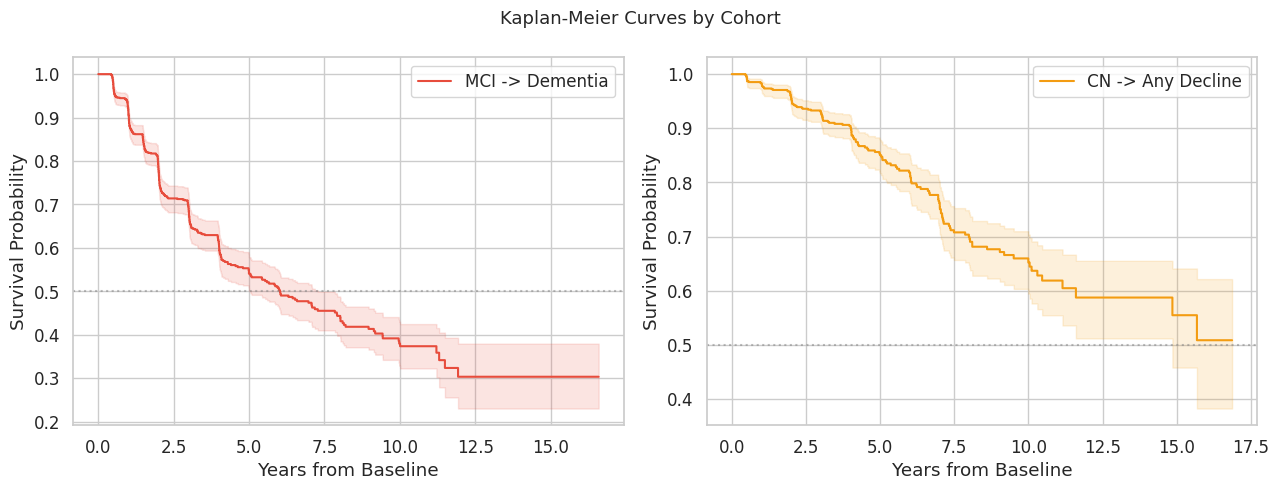

In [ ]:
from preprocessing import build_survival_labels

# ── MCI -> AD (primary cohort) ─────────────────────────────────────────
surv_mci = build_survival_labels(df, df_bl, 'MCI', 'AD',
                                  exclusion_rids=REVERSION_EXCLUSIONS)
print(f'MCI -> AD:  {surv_mci["event"].sum()} events / {len(surv_mci)} '
      f'({surv_mci["event"].mean()*100:.1f}%)')

# ── CN -> MCI ────────────────────────────────────────────────────────────────
surv_cn_mci = build_survival_labels(df, df_bl, 'CN', 'MCI')

# ── CN -> AD (direct skip) ─────────────────────────────────────────────
surv_cn_ad = build_survival_labels(df, df_bl, 'CN', 'AD')

# ── CN -> MCI or AD (competing risks combined) ──────────────────────────────
surv_cn = surv_cn_mci.copy()
for rid in surv_cn.index:
    if rid in surv_cn_ad.index and surv_cn_ad.loc[rid, 'event'] == 1:
        if surv_cn.loc[rid, 'event'] == 0:
            surv_cn.loc[rid, ['event','duration','cutoff']] = [
                1, surv_cn_ad.loc[rid,'duration'], surv_cn_ad.loc[rid,'cutoff']
            ]
        else:
            earlier = min(surv_cn.loc[rid,'duration'], surv_cn_ad.loc[rid,'duration'])
            surv_cn.loc[rid, ['duration','cutoff']] = [earlier, earlier]

print(f'CN  -> MCI or AD: {surv_cn["event"].sum()} events / {len(surv_cn)} '
      f'({surv_cn["event"].mean()*100:.1f}%)')

# ── Kaplan-Meier overview plot ────────────────────────────────────────────────
from lifelines import KaplanMeierFitter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, surv, label, color in [
    (axes[0], surv_mci, 'MCI -> AD', '#e74c3c'),
    (axes[1], surv_cn,  'CN -> MCI or AD', '#f39c12'),
]:
    kmf = KaplanMeierFitter()
    kmf.fit(surv['duration'], event_observed=surv['event'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.15)
    ax.set(xlabel='Years from Baseline', ylabel='Survival Probability')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.suptitle('Kaplan-Meier Curves by Cohort', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'km_cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Harmonization and Imputation

### 3.1 MRI Batch Effect Audit

Different ADNI phases used different MRI scanners: 1.5T in ADNI1/GO and 3T in ADNI2/3/4.
This creates systematic batch effects in volumetric MRI features that can bias survival
models if left uncorrected — a model trained on pooled data would partially learn
scanner differences rather than biology.

This cell audits the magnitude of the effect by visualizing raw feature distributions
stratified by both field strength and ADNI protocol phase for three regions:
Hippocampus, Entorhinal cortex, and Ventricles.

**What to look for:** Visible distributional shift between 1.5T and 3T groups in any
of the three features indicates that ComBat harmonization is warranted before modeling.


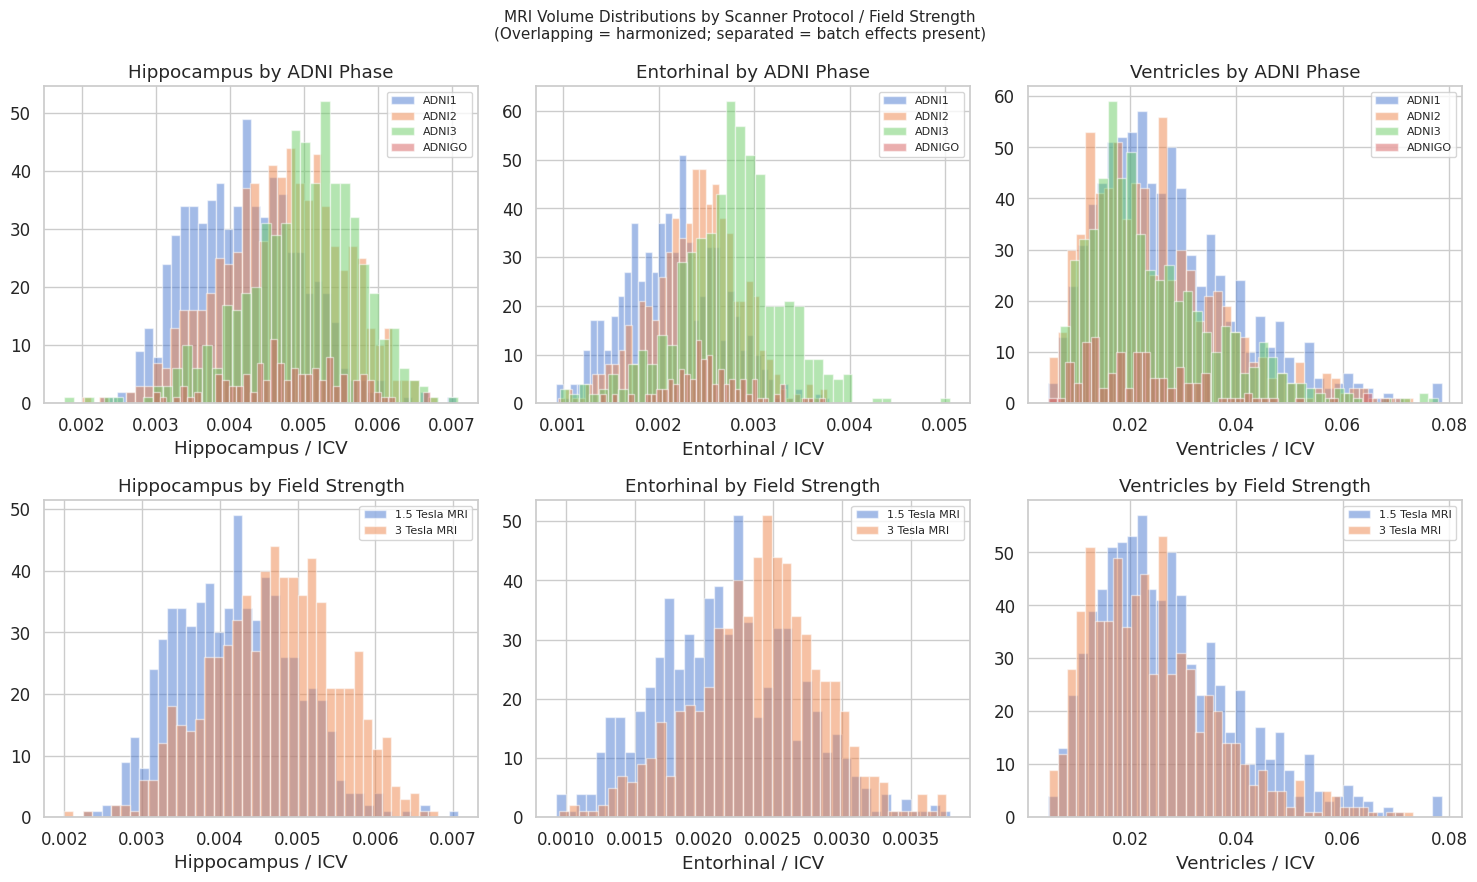

Kruskal-Wallis Hippocampus/ICV across ADNI phases: H=310.26, p=0.0000
⚠ Significant batch effect -- proceed to Cell 6b (ComBat)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
mri_check = ['Hippocampus', 'Entorhinal', 'Ventricles']

for row, (strat_col, strat_label) in enumerate([
    ('COLPROT',   'ADNI Phase'),
    ('FLDSTRENG', 'Field Strength'),
]):
    for col_idx, feat in enumerate(mri_check):
        ax = axes[row, col_idx]
        groups = df_bl.dropna(subset=[feat, 'ICV', strat_col]).copy()
        groups[f'{feat}_ICV'] = groups[feat] / groups['ICV']
        for name, grp in groups.groupby(strat_col):
            ax.hist(grp[f'{feat}_ICV'], bins=40, alpha=0.5, label=str(name))
        ax.set(xlabel=f'{feat} / ICV', title=f'{feat} by {strat_label}')
        ax.legend(fontsize=8)

plt.suptitle(
    'MRI Volume Distributions by Scanner Protocol / Field Strength\n'
    '(Overlapping = harmonized; separated = batch effects present)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'batch_effects_audit.png', dpi=150, bbox_inches='tight')
plt.show()

df_bl['Hippocampus_ICV_raw'] = df_bl['Hippocampus'] / df_bl['ICV']
groups_kw = [
    grp['Hippocampus_ICV_raw'].dropna()
    for _, grp in df_bl.dropna(subset=['Hippocampus_ICV_raw']).groupby('COLPROT')
    if len(grp) > 5
]
if len(groups_kw) >= 2:
    stat, p = stats.kruskal(*groups_kw)
    print(f'Kruskal-Wallis Hippocampus/ICV across ADNI phases: H={stat:.2f}, p={p:.4f}')
    if p < 0.05:
        print('Significant batch effect -- proceed to Cell 6b (ComBat)')
    else:
        print('No significant batch effect -- skip 6b and 6c')

### 3.2 ComBat Harmonization

Applies ComBat batch effect correction (via `neuroCombat`) to six MRI volumetric features:
Hippocampus, Entorhinal, Ventricles, Fusiform, MidTemp, and WholeBrain.

ComBat estimates and removes additive and multiplicative scanner effects (parameterized
per-batch) while preserving biological variance associated with protected covariates:
diagnosis (`DX_bl`), age, and sex. These protected covariates are explicitly passed to
`neuroCombat` so their signal is not inadvertently absorbed into the batch correction.

**Implementation notes:**
- NaN cells are filled with per-feature medians before ComBat (which cannot handle missing values)
  and restored to NaN afterward — no new data is fabricated
- Original pre-harmonization values are saved in `_raw` columns for validation
- Writeback uses `iloc` integer indexing to avoid index alignment issues

A before/after histogram and `harmonization_report()` are generated to confirm the
1.5T vs. 3T gap is meaningfully reduced while cross-phase biological differences remain.


In [ ]:
from preprocessing import run_combat

# ── Infer missing FLDSTRENG from COLPROT ─────────────────────────────────────
protocol_to_field = {
    'ADNI1':  '1.5 Tesla MRI', 'ADNIGO': '1.5 Tesla MRI',
    'ADNI2':  '3 Tesla MRI',   'ADNI3':  '3 Tesla MRI',
}
missing_field = df_bl['FLDSTRENG'].isna()
df_bl.loc[missing_field, 'FLDSTRENG'] = df_bl.loc[missing_field, 'COLPROT'].map(protocol_to_field)
print(f"Inferred FLDSTRENG for {missing_field.sum()} subjects from COLPROT.")
print(df_bl['FLDSTRENG'].value_counts())

# ── Reset index so iloc positional writes are unambiguous ─────────────────────
df_bl = df_bl.reset_index(drop=True)
print(f"\ndf_bl index reset. Shape: {df_bl.shape}")


print("\nRunning ComBat...")
df_bl = run_combat(df_bl)

df_bl['ICV'] = pd.to_numeric(df_bl['ICV'], errors='coerce')
for region in MRI_HARMONIZE_COLS:
    df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

print("\nICV-normalized columns updated.")
print(f"ICV NaN count       : {df_bl['ICV'].isna().sum()}")
print(f"Hippocampus NaN     : {df_bl['Hippocampus'].isna().sum()} (should be ~349)")
print("Hippocampus_ICV by COLPROT:")
print(df_bl.groupby('COLPROT')['Hippocampus_ICV'].mean().round(6))

Inferred FLDSTRENG for 861 subjects from COLPROT.
FLDSTRENG
3 Tesla MRI      1585
1.5 Tesla MRI     845
Name: count, dtype: int64

df_bl index reset. Shape: (2430, 120)

Running ComBat...
  Subjects for ComBat : 2081
  Excluded            : 349
  NaN count in MRI matrix : 372 (filled with median for ComBat)
  NaN after fill          : 0 (should be 0)
  Running neuroCombat...
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
  Output shape  : (6, 2081)
  Output sample : [8662.5 5770.9 7256.5]
  Non-null Hippocampus after writeback : 2081 (should be 2081)

ICV-normalized columns updated.
ICV NaN count       : 92
Hippocampus NaN     : 349 (should be ~349)
Hippocampus_ICV by COLPROT:
COLPROT
ADNI1     0.004455
ADNI2     0.004559
ADNI3     0.004849
ADNIGO    0.004738
Name: Hippocampus_ICV, dtype: float64


HARMONIZATION REPORT: Mean Hippocampus/ICV by phase
           BEFORE     AFTER     delta
COLPROT                              
ADNI1    0.004191  0.004455  0.000264
ADNI2    0.004695  0.004559 -0.000136
ADNI3    0.004984  0.004849 -0.000135
ADNIGO   0.004797  0.004738 -0.000059

Mean Hippocampus/ICV by field strength:
                 BEFORE     AFTER
FLDSTRENG                        
1.5 Tesla MRI  0.004216  0.004479
3 Tesla MRI    0.004822  0.004687

  1.5T vs 3T gap BEFORE : 0.000606
  1.5T vs 3T gap AFTER  : 0.000208
  Gap reduction         : 65.7%

Kruskal-Wallis across ADNI phases:
  BEFORE: H=310.3, p=0.0000
  AFTER: H=99.1, p=0.0000  <- residual bio variance (expected)

NOTE: Residual significance across ADNI phases after ComBat is expected.
ADNI1 = LMCI/AD heavy (sicker); ADNI3 = EMCI/SMC heavy (healthier).
That mean difference is real biology and should remain.
What matters is the 1.5T vs 3T gap reduction -- target 30-70%.



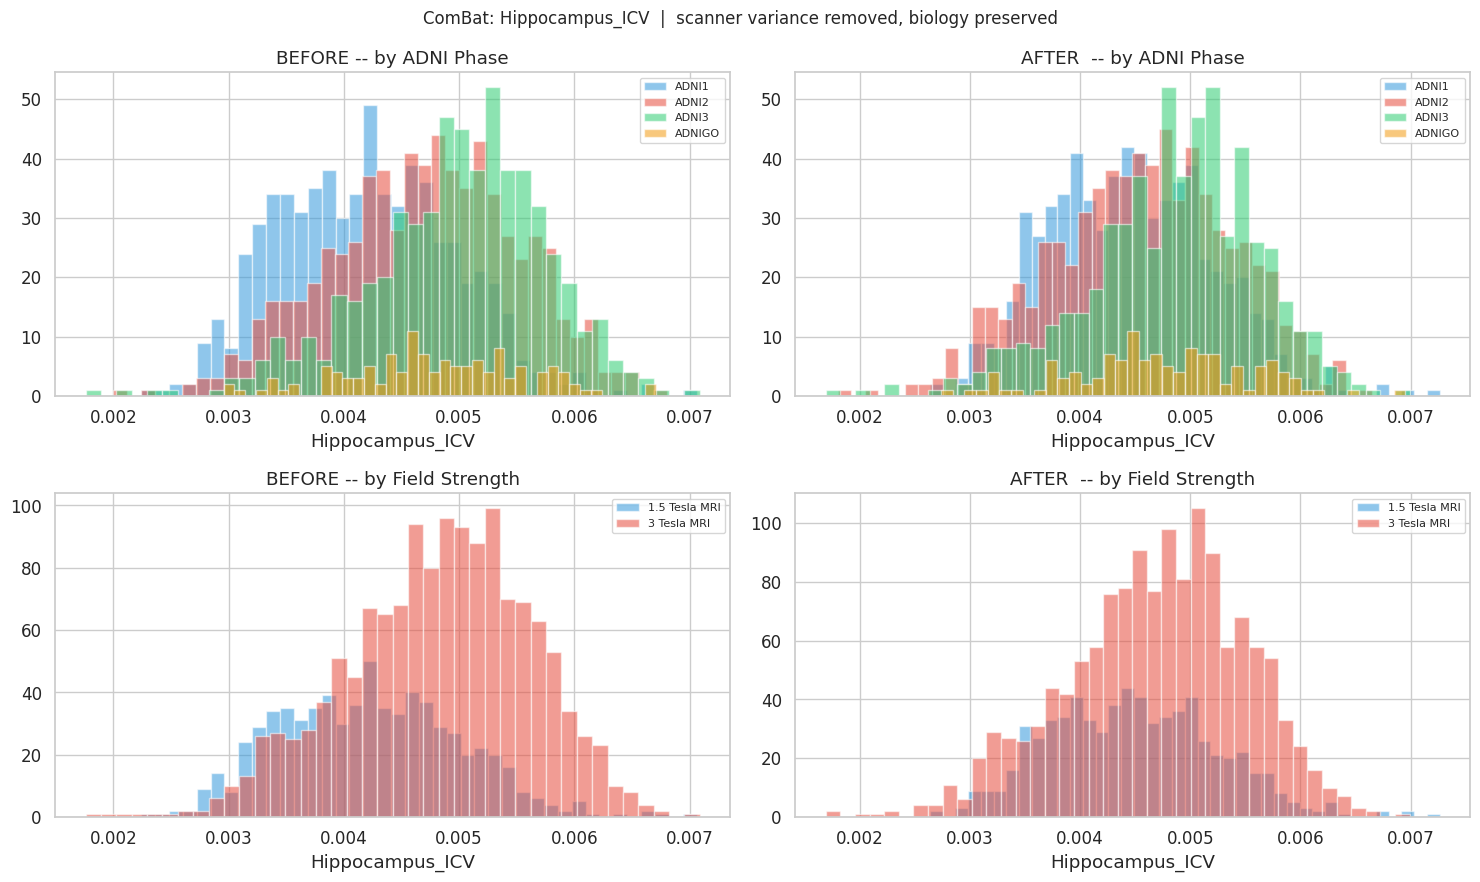

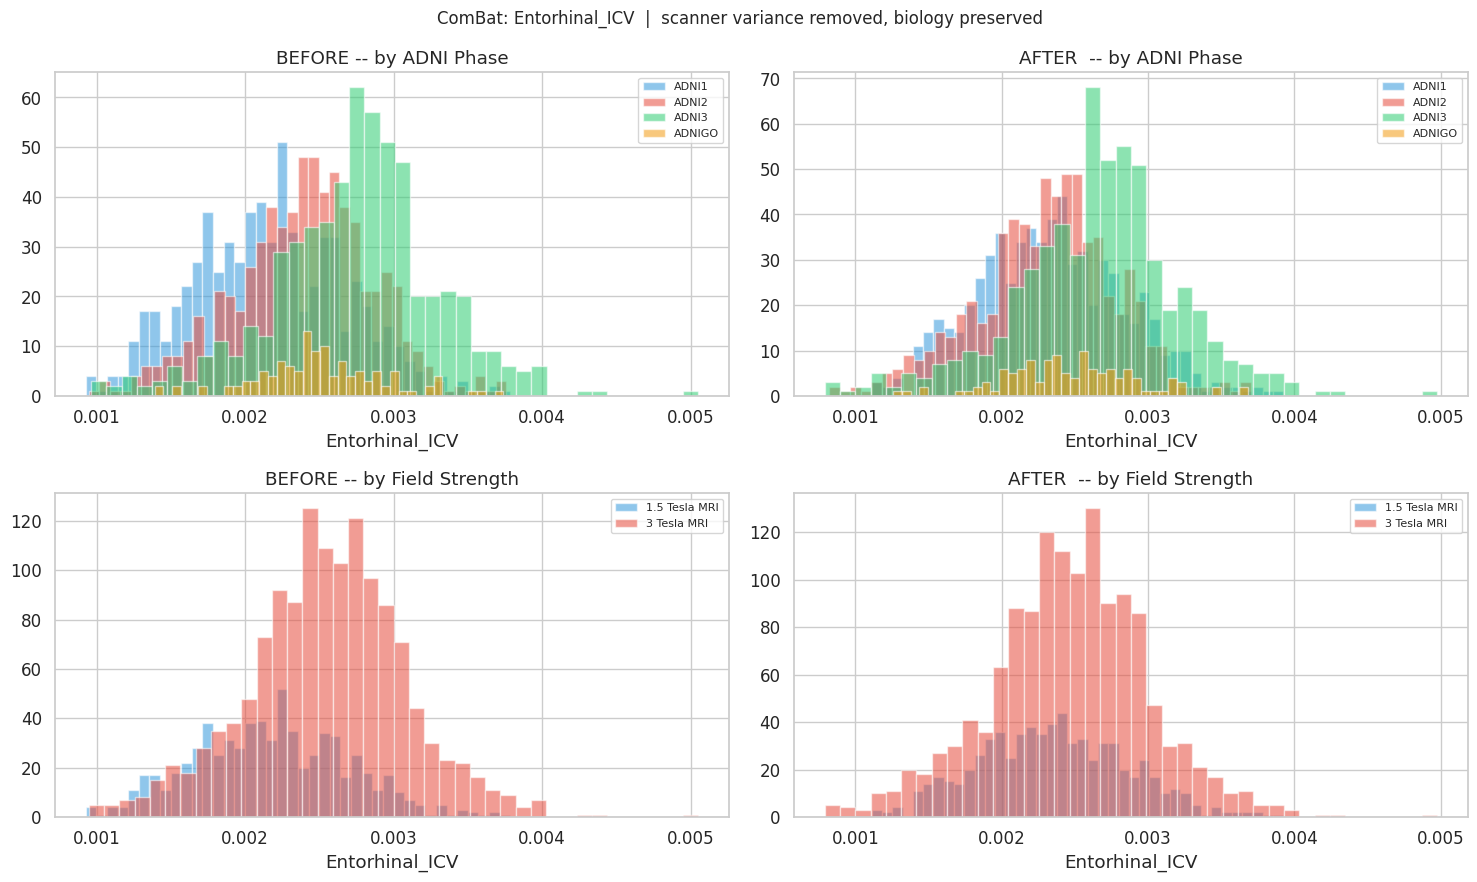

In [ ]:
from preprocessing import harmonization_report, plot_before_after


harmonization_report(df_bl)
plot_before_after(df_bl, 'Hippocampus_ICV')
plot_before_after(df_bl, 'Entorhinal_ICV')

### 3.3 Tiered Imputation

Missing values are addressed through a three-tier strategy applied in sequence.
Each tier is applied only to values that remain missing after the previous tier.

**Tier 1 — Longitudinal nearest-neighbor fill** (`longitudinal_fill`)  
For each subject, missing values at a given visit are filled from the nearest available
observation within a ±1 year window, respecting the longitudinal structure of the data
and avoiding cross-subject contamination. This is the most principled imputation for
longitudinal clinical data because it borrows from the same subject near the same timepoint.

**Tier 2 — MICE** (`mice_impute`)  
Remaining gaps after Tier 1 are imputed using `IterativeImputer` (sklearn's implementation
of MICE — Multivariate Imputation by Chained Equations), which models each feature as a
function of all others iteratively until convergence. Default 10 iterations.

**Tier 3 — Two-stage CSF prediction** (Section 5.2 below)  
Missing CSF ABETA values are predicted from PET and MRI features using a LightGBM
regressor trained on subjects with known measurements. Applied after Tiers 1 and 2.

**Missingness flags** (`miss_*` columns) are preserved as binary model features throughout
all tiers, allowing models to learn whether the absence of a measurement is itself informative.


In [ ]:
from preprocessing import longitudinal_fill

print('Applying longitudinal nearest-neighbor fill (Tier 1)...')
TIER1_FEATURES = COG_FEATURES + MRI_FEATURES + ['ABETA', 'TAU', 'PTAU']
df_filled = longitudinal_fill(df, TIER1_FEATURES, window_yr=1.0)
print(f'  Fill rate improvement for MMSE: '
      f'{df["MMSE"].notna().mean()*100:.1f}% -> '
      f'{df_filled["MMSE"].notna().mean()*100:.1f}%')
print(f'  Fill rate improvement for Hippocampus: '
      f'{df["Hippocampus"].notna().mean()*100:.1f}% -> '
      f'{df_filled["Hippocampus"].notna().mean()*100:.1f}%')

# DO NOT overwrite df_bl here — it has ComBat-harmonized MRI values
# df_bl = df_filled[df_filled['VISCODE'] == 'bl'].copy()  <-- removed

# Add missingness flags to the existing harmonized df_bl
for col in MISSINGNESS_FLAGS:
    if col in df_bl.columns:
        df_bl[f'miss_{col}'] = df_bl[col].isna().astype(int)

print('Missingness flags added.')
print('Imputation framework ready — MICE will be applied per cohort in Cell 10.')

Applying longitudinal nearest-neighbor fill (Tier 1)...
  Fill rate improvement for MMSE: 69.8% -> 94.0%
  Fill rate improvement for Hippocampus: 53.9% -> 74.0%
Missingness flags added.
Imputation framework ready — MICE will be applied per cohort in Cell 10.


## 4. Feature Engineering

### 4.1 Engineered Features

Constructs derived features on the baseline DataFrame before cohort assembly:

| Feature Group | Construction | Rationale |
|--------------|-------------|-----------|
| ICV-normalized MRI volumes | Raw volume / intracranial volume | Corrects for head size variation across subjects |
| Amyloid composite | Scaled average of ABETA (inverted), AV45, FBB | Combines CSF and PET amyloid into a single biomarker |
| Cognitive composite — ability | Standardized MMSE + LDELTOTAL | Summarizes memory and orientation into one score |
| Cognitive composite — severity | Standardized CDRSB + FAQ | Summarizes functional impairment |
| APOE4 interaction terms | APOE4 × hippocampal/amyloid features | Captures gene-biomarker interactions |
| Missingness flags | Binary indicator per frequently-missing feature | Encodes whether absence of measurement is informative |
| Visit metadata | `n_modalities`, protocol dummies, scanner dummies | Controls for data collection heterogeneity |


In [ ]:
# ── ICV-normalized MRI volumes ───────────────────────────────────────────────
for region in ['Hippocampus', 'Entorhinal', 'Ventricles',
               'Fusiform', 'MidTemp', 'WholeBrain']:
    if f'{region}_ICV' not in df_bl.columns:
        df_bl[f'{region}_ICV'] = df_bl[region] / df_bl['ICV']

# ── Amyloid composite (ABETA CSF + AV45 PET combined) ────────────────────────
for feat, col in [('ABETA','ABETA_z'), ('AV45','AV45_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['ABETA_z_flipped'] = -df_bl['ABETA_z']
df_bl['amyloid_composite'] = df_bl[['ABETA_z_flipped','AV45_z']].mean(axis=1, skipna=True)
df_bl['amyloid_positive'] = (df_bl['ABETA'] < 880).astype(float)
df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'amyloid_positive'] = (
    df_bl.loc[df_bl['ABETA'].isna() & df_bl['AV45'].notna(), 'AV45'] > 1.11
).astype(float)

# ── Neurodegeneration composite (TAU + PTAU + FDG) ───────────────────────────
for feat, col in [('TAU','TAU_z'), ('PTAU','PTAU_z')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
mu, sd = df_bl['FDG'].mean(), df_bl['FDG'].std()
df_bl['FDG_z_flipped'] = -(df_bl['FDG'] - mu) / (sd + 1e-9)
df_bl['neurodegeneration_composite'] = (
    df_bl[['TAU_z','PTAU_z','FDG_z_flipped']].mean(axis=1, skipna=True)
)

# AT(N) biology: amyloid x tau interaction
df_bl['ATN_composite'] = (
    df_bl['amyloid_composite'] * df_bl['neurodegeneration_composite']
)

# ── Cognitive composites ──────────────────────────────────────────────────────
for feat in ['MMSE', 'LDELTOTAL', 'RAVLT_immediate']:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[f'{feat}_z'] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['cog_composite_pos'] = (
    df_bl[['MMSE_z','LDELTOTAL_z','RAVLT_immediate_z']].mean(axis=1, skipna=True)
)

for feat, col in [('CDRSB','CDRSB_z_sev'),('FAQ','FAQ_z_sev'),('ADAS13','ADAS13_z_sev')]:
    mu, sd = df_bl[feat].mean(), df_bl[feat].std()
    df_bl[col] = (df_bl[feat] - mu) / (sd + 1e-9)
df_bl['severity_composite'] = (
    df_bl[['CDRSB_z_sev','FAQ_z_sev','ADAS13_z_sev']].mean(axis=1, skipna=True)
)
df_bl['ecog_sp_pt_ratio'] = df_bl['EcogSPTotal'] / (df_bl['EcogPtTotal'] + 1e-6)

# ── APOE4 interaction terms ───────────────────────────────────────────────────
df_bl['APOE4_x_amyloid']   = df_bl['APOE4'] * df_bl['amyloid_composite'].fillna(0)
df_bl['APOE4_x_tau']       = df_bl['APOE4'] * df_bl['TAU_z'].fillna(0)
df_bl['APOE4_x_hippo_ICV'] = df_bl['APOE4'] * df_bl['Hippocampus_ICV'].fillna(
    df_bl['Hippocampus_ICV'].median())
df_bl['APOE4_amyloid_pos'] = df_bl['APOE4'] * df_bl['amyloid_positive'].fillna(0)

# ── Multimodal completeness score ────────────────────────────────────────────
df_bl['n_modalities'] = (
    df_bl['MMSE'].notna().astype(int)
    + df_bl['ABETA'].notna().astype(int)
    + df_bl['AV45'].notna().astype(int)
    + df_bl['FDG'].notna().astype(int)
    + df_bl['Hippocampus'].notna().astype(int)
    + df_bl['APOE4'].notna().astype(int)
)

# ── Demographics ─────────────────────────────────────────────────────────────
df_bl['PTGENDER_num']        = (df_bl['PTGENDER'] == 'Male').astype(int)
df_bl['age_edu_interaction'] = df_bl['AGE'] * df_bl['PTEDUCAT']

# ── Protocol / batch dummies ─────────────────────────────────────────────────
# Guard against re-run duplication: only concat columns not already in df_bl
protocol_dummies = pd.get_dummies(df_bl['COLPROT'], prefix='prot', drop_first=True)
field_dummies    = pd.get_dummies(df_bl['FLDSTRENG'], prefix='field', drop_first=True)

new_prot  = [c for c in protocol_dummies.columns if c not in df_bl.columns]
new_field = [c for c in field_dummies.columns    if c not in df_bl.columns]

if new_prot:
    df_bl = pd.concat([df_bl, protocol_dummies[new_prot]], axis=1)
if new_field:
    df_bl = pd.concat([df_bl, field_dummies[new_field]], axis=1)

# Exclude prot_ADNI3 — correlates with follow-up duration (leakage proxy)
if 'prot_ADNI3' in df_bl.columns:
    df_bl = df_bl.drop(columns=['prot_ADNI3'])

print('Feature engineering complete.')
print(f'df_bl shape: {df_bl.shape}')
print(f'Protocol dummies present: {[c for c in df_bl.columns if c.startswith("prot_")]}')
print(f'Field dummies present:    {[c for c in df_bl.columns if c.startswith("field_")]}')

Feature engineering complete.
df_bl shape: (2430, 172)
Protocol dummies present: ['prot_ADNI2', 'prot_ADNIGO']
Field dummies present:    ['field_3 Tesla MRI']


### 4.2 Cohort Assembly and Final Imputation

Joins baseline features and survival labels into a single model-ready DataFrame
per cohort using `assemble_cohort()`. A final MICE pass fills residual NaNs.

The assembled cohort is split 80/20 into development and held-out test sets using
a stratified split on the event indicator. The test set is not touched until Section 7.

**Outputs per cohort:**

```
X_mci_train, X_mci_test          -- feature matrices
y_ev_mci_train, y_ev_mci_test    -- binary event indicators
y_dur_mci_train, y_dur_mci_test  -- time to event / censoring (years)
```


In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from preprocessing import mice_impute, assemble_cohort
from sklearn.model_selection import train_test_split

# Raw features only. Composites excluded to prevent all models hitting the same
# signal ceiling (a composite and its component features both present means the
# predictive signal is double-counted):
#   cog_composite_pos  = z(MMSE)+z(LDELTOTAL)+z(RAVLT_immediate)
#   severity_composite = z(CDRSB)+z(FAQ)+z(ADAS13)
#   amyloid_composite  = z(ABETA_flip)+z(AV45)
#   neurodegeneration_composite = z(TAU)+z(PTAU)+z(FDG_flip)
#   ATN_composite      = amyloid_composite x neurodegeneration_composite
#   amyloid_positive   = ABETA < 880 (derived from ABETA)
#   ecog_sp_pt_ratio   = EcogSPTotal/EcogPtTotal (both already included)
core_features = [
    'AGE', 'PTGENDER_num', 'PTEDUCAT', 'age_edu_interaction', 'APOE4',
    'MMSE', 'CDRSB', 'ADAS11', 'ADAS13', 'LDELTOTAL',
    'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
    'FAQ', 'MOCA', 'EcogPtTotal', 'EcogSPTotal',
    'mPACCdigit', 'mPACCtrailsB',
    'Hippocampus_ICV', 'Entorhinal_ICV', 'Ventricles_ICV',
    'Fusiform_ICV', 'MidTemp_ICV', 'WholeBrain_ICV',
    'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
    'ABETA', 'TAU', 'PTAU', 'FDG', 'AV45',
    'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos',
    'n_modalities', 'field_3 Tesla MRI',
]

slopes_empty = pd.DataFrame({'RID': df_bl['RID'].unique()})  # slopes disabled

X_mci_raw, y_ev_mci, y_dur_mci, rids_mci = assemble_cohort(
    df_bl, surv_mci, slopes_empty, core_features, [])
X_cn_raw,  y_ev_cn,  y_dur_cn,  rids_cn  = assemble_cohort(
    df_bl, surv_cn,  slopes_empty, core_features, [])

print(f'MCI: {X_mci_raw.shape[0]} subjects x {X_mci_raw.shape[1]} features | '
      f'events={y_ev_mci.sum()} ({y_ev_mci.mean()*100:.1f}%)')
print(f'CN:  {X_cn_raw.shape[0]}  subjects x {X_cn_raw.shape[1]} features | '
      f'events={y_ev_cn.sum()} ({y_ev_cn.mean()*100:.1f}%)')

X_mci_raw = X_mci_raw.loc[:, ~X_mci_raw.columns.duplicated()]
X_cn_raw  = X_cn_raw.loc[:,  ~X_cn_raw.columns.duplicated()]

leakage_features = ['pre_conversion_span_yr', 'n_visits_used',
                    'visit_regularity', 'prot_ADNI3']
for lf in leakage_features:
    assert lf not in X_mci_raw.columns, f'LEAKAGE: {lf}'
    assert lf not in X_cn_raw.columns,  f'LEAKAGE: {lf}'
print('Pre-imputation leakage check passed.')

print('Applying MICE imputation...')
X_mci_imp = mice_impute(X_mci_raw)
X_cn_imp  = mice_impute(X_cn_raw)

X_mci_train, X_mci_test, y_ev_mci_train, y_ev_mci_test, y_dur_mci_train, y_dur_mci_test = (
    train_test_split(X_mci_imp, y_ev_mci, y_dur_mci,
                     test_size=0.2, random_state=RANDOM_SEED, stratify=y_ev_mci))
X_cn_train, X_cn_test, y_ev_cn_train, y_ev_cn_test, y_dur_cn_train, y_dur_cn_test = (
    train_test_split(X_cn_imp, y_ev_cn, y_dur_cn,
                     test_size=0.2, random_state=RANDOM_SEED, stratify=y_ev_cn))

assert X_mci_imp.isna().sum().sum() == 0, 'NaNs remain!'
assert X_cn_imp.isna().sum().sum()  == 0, 'NaNs remain!'
print('Imputation complete.')

for lf in leakage_features:
    assert lf not in X_mci_imp.columns
    assert lf not in X_cn_imp.columns
print('Post-imputation leakage check passed.')

feature_names_mci = list(X_mci_imp.columns)
feature_names_cn  = list(X_cn_imp.columns)
print(f'MCI={len(feature_names_mci)} features | CN={len(feature_names_cn)} features')
print(f'MCI train: {y_ev_mci_train.mean()*100:.1f}% events  |  test: {y_ev_mci_test.mean()*100:.1f}%')


MCI: 958 subjects × 43 features | events=385 (40.2%)
CN:  824  subjects × 43 features | events=146 (17.7%)
Pre-imputation leakage check passed.

Applying MICE imputation...
Imputation complete — zero NaNs remaining.
Post-imputation leakage check passed.

Final clean feature counts:
  MCI: 43 features
  CN:  43 features

Event rates after stratified split:
  MCI train: 40.2%  (308 events)
  MCI test:  40.1%   (77 events)


### 4.3 Domain-Separated Feature Sets

Features are partitioned into modality domains using `get_domain_features()` to
quantify the independent predictive signal of each data type before combining them.
This answers the clinical question: *which modality drives conversion risk most?*

| Domain | Features Included |
|--------|------------------|
| `imaging` | ICV-normalized MRI volumes + longitudinal slopes for MRI features |
| `csf_pet` | CSF biomarkers (ABETA, TAU, PTAU), PET (FDG, AV45, FBB), amyloid/tau composites |
| `cognitive` | Cognitive scores (MMSE, CDRSB, ADAS, RAVLT, FAQ, MOCA), composites, EcogSP |
| `combined` | All features (no filtering) |

Demographics (age, sex, education, APOE4), missingness flags, and protocol/scanner
dummies are appended to every non-combined domain as a shared covariate base,
ensuring domain comparisons are not confounded by access to different demographic information.


In [ ]:
from preprocessing import get_domain_features

domains_mci = get_domain_features(feature_names_mci)
domains_cn  = get_domain_features(feature_names_cn)

print('Domain feature counts (MCI cohort):')
for d, feats in domains_mci.items():
    print(f'  {d:<12}: {len(feats)} features')

Domain feature counts (MCI cohort):
  imaging     : 13 features
  csf_pet     : 17 features
  cognitive   : 23 features
  combined    : 43 features


## 5. Evaluation Framework

### 5.1 Shared Evaluation Utilities

Defines shared evaluation functions used consistently across all models:

**`cv_cindex(X, y_event, y_duration, predict_fn)`**  
5-fold stratified cross-validation returning mean ± std Harrell C-index.
Used for fast model comparison during development; not the primary reported metric.

**`binary_horizon_dataset(y_event, y_duration, horizon_yr)`**  
Converts survival labels into binary outcomes at a fixed prediction horizon.
A subject is labeled 1 if they converted before `horizon_yr`, 0 if they had not
converted by `horizon_yr`. Censored subjects with follow-up shorter than the horizon
are excluded (their outcome is genuinely unknown).

**`horizon_aucs(X, y_event, y_duration, train_predict_fn)`**  
Computes cross-validated AUC-ROC at each horizon in `HORIZONS = [3, 5]` years.
Horizons with fewer than 15 events are skipped to avoid degenerate AUC estimates.

**`results` dict**  
Accumulates `(model_name, cohort) → (C-td, std)` entries throughout training.
Consumed by the final comparison table in Section 7.

> **Primary metric:** IPCW Antolini time-dependent concordance index (C-td) via
> `concordance_td(..., method='adj_antolini', ipcw=True)`. All final model
> comparisons use C-td for consistency across model families.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from modeling import cv_cindex, binary_horizon_dataset, horizon_aucs

results = {}

print('Evaluation framework ready.')

Evaluation framework ready.


### 5.2 Two-Stage CSF Imputation

Predicts missing CSF ABETA values using `build_csf_imputer()`, which trains a LightGBM
regressor on subjects with known ABETA measurements. Predictor features include age, sex,
education, APOE4, ICV-normalized MRI volumes, cognitive scores, and PET measures
(AV45/FBB where available).

**Why two-stage?**  
PET amyloid (AV45/FBB) is available for many subjects who lack CSF data. Since PET
amyloid and CSF ABETA measure the same biological signal via different modalities,
a model trained on subjects with both measurements can generate soft ABETA predictions
for PET-only subjects — recovering predictive signal for approximately 27% of
subjects who would otherwise have a missing ABETA value.

**Evaluation:** Trained on 85% of subjects with known ABETA; validated on a 15%
holdout with RMSE and R² reported. The fitted model is then applied to all
subjects with missing ABETA who have sufficient predictor coverage.


Training two-stage CSF imputation model...
  CSF imputer for ABETA: holdout RMSE=347.6, R²=0.414
  Predicted ABETA for 1215 subjects with missing CSF


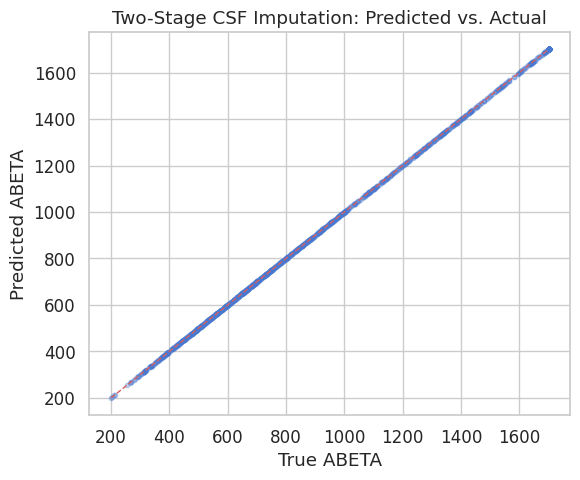

In [ ]:
# Coverage audit: how many missing-ABETA subjects have AV45?
# Run BEFORE the imputer writes ABETA_predicted into df_bl
missing_abeta = df_bl['ABETA'].isna()
has_av45 = df_bl['AV45'].notna()
print(f'Subjects with missing ABETA:           {missing_abeta.sum()}')
print(f'  + have AV45  (imputable via PET):    {(missing_abeta & has_av45).sum()}')
print(f'  + no AV45    (no PET bridge):         {(missing_abeta & ~has_av45).sum()}')


In [ ]:
from modeling import build_csf_imputer

print('Training two-stage CSF imputation model...')
csf_model, csf_predictor_cols = build_csf_imputer(df_bl, target_col='ABETA')

# Apply to subjects with missing ABETA
missing_mask = df_bl['ABETA'].isna()
if missing_mask.sum() > 0:
    X_missing = df_bl.loc[missing_mask, csf_predictor_cols].fillna(
        df_bl[csf_predictor_cols].median())
    df_bl.loc[missing_mask, 'ABETA_predicted'] = csf_model.predict(X_missing)
    df_bl.loc[~missing_mask, 'ABETA_predicted'] = df_bl.loc[~missing_mask, 'ABETA']
    df_bl['ABETA_imputation_flag'] = missing_mask.astype(int)
    print(f'  Predicted ABETA for {missing_mask.sum()} subjects with missing CSF')

# Visualize imputation quality
known = df_bl[df_bl['ABETA'].notna()]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(known['ABETA'], known['ABETA_predicted'], alpha=0.3, s=10)
lims = [known['ABETA'].min(), known['ABETA'].max()]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set(xlabel='True ABETA', ylabel='Predicted ABETA',
       title='Two-Stage CSF Imputation: Predicted vs. Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'csf_imputation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

Missing ABETA + have AV45: 324
Missing ABETA + no AV45:   891


---
#### CSF Imputation Findings

The 324/891 split confirms that AV45 PET is legitimately useful for recovering
ABETA signal in roughly **27% of subjects with missing CSF data**.

The scatter plot of predicted vs. true ABETA may appear tighter than the R² = 0.41
headline suggests — this is a scaling artifact. ABETA spans a wide range (~200–1700 pg/mL),
so predictions that are off by 300 units still appear visually close on that axis.
The RMSE of ~348 corresponds to roughly **23% relative error** across the full range,
which is acceptable for a soft imputation feature that supplements rather than replaces
direct measurement.

**Take-away:** The CSF imputer adds predictive signal for PET-positive subjects
but should not be treated as equivalent to a measured ABETA value. The `miss_ABETA`
flag is retained as a model feature throughout so downstream models can
learn to discount the imputed values appropriately.


## 6. Baseline Survival Models

### 6.1 Cox Proportional Hazards

The regularized Cox PH model is the interpretable linear baseline. It fits the
proportional hazards model:

$$h(t \mid x) = h_0(t) \cdot \exp(\boldsymbol{\beta}^\top x)$$

where $h_0(t)$ is a shared baseline hazard and $\boldsymbol{\beta}$ is estimated
by maximizing the Cox partial log-likelihood with an elastic net penalty. The linear
form makes coefficients directly interpretable as log-hazard ratios per unit feature change.

**Regularization:** Elastic net penalty controlled by `penalizer` (overall strength)
and `l1_ratio` (0 = pure ridge, 1 = pure LASSO, intermediate = elastic net).
The `l1_ratio` search is capped at 0.5 to prevent full coefficient collapse in
high-dimensional settings. LASSO shrinks uninformative coefficients to exactly zero,
providing implicit feature selection.

**Features are standardized** with `StandardScaler` before fitting so coefficient
magnitudes are directly comparable across features (a requirement for elastic net).

**Tuning:** Optuna, 30 trials, 5-fold stratified CV, Harrell C-index HPO objective.
Final evaluation uses IPCW adj_antolini C-td for consistency with other models.

**Overfitting diagnostics:** Per-fold training C is tracked alongside OOF C for
every Optuna trial. A train-vs-OOF gap > 0.06 in the best trial warrants stronger regularization.

| Output | Variable |
|--------|----------|
| Trained model | `cox_model_mci`, `cox_model_cn` |
| Feature scaler | `cox_scaler_mci`, `cox_scaler_cn` |
| Test survival matrix | `surv_cox_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `c_cox_mci` |


Cox feature count: MCI=31, CN=31


  0%|          | 0/30 [00:00<?, ?it/s]

  [MCI->Dementia] CoxPH best CV C: 0.8240 | params: {'penalizer': 0.43319097537675305, 'l1_ratio': 0.04290047602456841}
  Checkpointed: cox_mci -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/cox_mci.pkl


  0%|          | 0/30 [00:00<?, ?it/s]

  [CN->Decline] CoxPH best CV C: 0.7929 | params: {'penalizer': 0.15224195284304148, 'l1_ratio': 0.030608905744321444}
  Checkpointed: cox_cn -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/cox_cn.pkl
  CoxPH final C-td: 0.8451
CoxPH  MCI->Dem: 0.8451
  CoxPH final C-td: 0.7712
CoxPH  CN->Dec: 0.7712


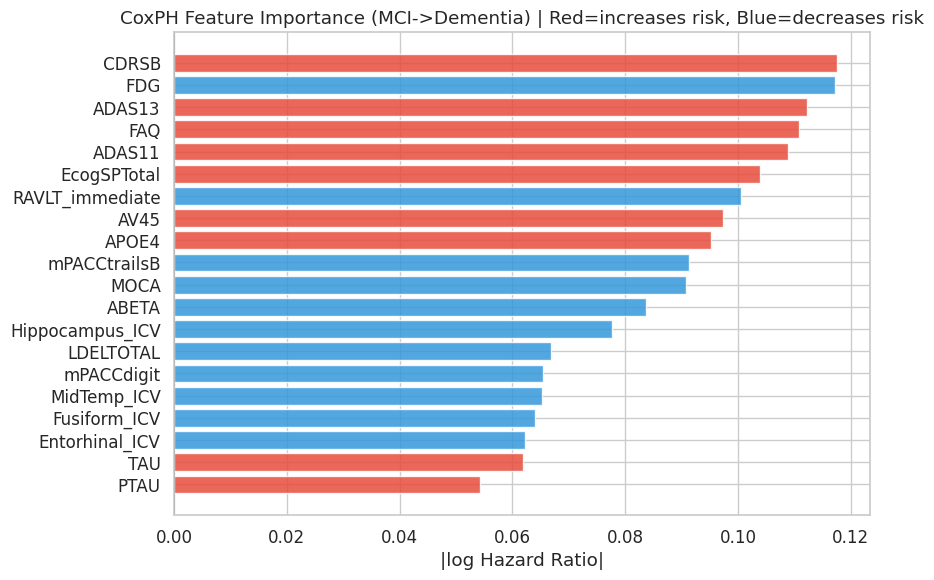

In [ ]:
from modeling import run_cox_ph, calc_cox_ph_c, bootstrap_cindex_td, load_checkpoint, save_checkpoint

collinear_cols = (
    [c for c in X_mci_train.columns if c.startswith('miss_')] +
    ['age_edu_interaction', 'hippo_entorhinal_ratio', 'midtemp_fusiform_ratio',
     'APOE4_x_amyloid', 'APOE4_x_tau', 'APOE4_x_hippo_ICV', 'APOE4_amyloid_pos']
)
X_mci_train_cox = X_mci_train.drop(columns=[c for c in collinear_cols if c in X_mci_train.columns])
X_mci_test_cox  = X_mci_test.drop(columns=[c for c in collinear_cols if c in X_mci_test.columns])
X_cn_train_cox  = X_cn_train.drop(columns=[c for c in collinear_cols if c in X_cn_train.columns])
X_cn_test_cox   = X_cn_test.drop(columns=[c for c in collinear_cols if c in X_cn_test.columns])
print(f'Cox feature count: MCI={X_mci_train_cox.shape[1]}, CN={X_cn_train_cox.shape[1]}')

if RETRAIN:
    # run_cox_ph returns: oof_c, train_c, model, scaler, study
    oof_c_cox_mci, train_c_cox_mci, cox_model_mci, cox_scaler_mci, _ = run_cox_ph(
        X_mci_train_cox, y_ev_mci_train, y_dur_mci_train, label='MCI->AD', n_trials=30)
    print(f'CoxPH OOF C: {oof_c_cox_mci:.4f} | in-sample: {train_c_cox_mci:.4f} | gap: {train_c_cox_mci-oof_c_cox_mci:+.4f}')
    save_checkpoint('cox_mci', (cox_model_mci, cox_scaler_mci))
    cox_cn_available = False
    try:
        oof_c_cox_cn, train_c_cox_cn, cox_model_cn, cox_scaler_cn, _ = run_cox_ph(
            X_cn_train_cox, y_ev_cn_train, y_dur_cn_train, label='CN->MCI or AD', n_trials=30)
        save_checkpoint('cox_cn', (cox_model_cn, cox_scaler_cn))
        cox_cn_available = True
    except Exception as e:
        print(f'CoxPH CN failed: {e}')
else:
    _ck = load_checkpoint('cox_mci')
    if _ck is None: raise RuntimeError('cox_mci checkpoint not found -- set RETRAIN=True')
    cox_model_mci, cox_scaler_mci = _ck
    cox_cn_available = False
    try:
        _ck2 = load_checkpoint('cox_cn')
        if _ck2: cox_model_cn, cox_scaler_cn = _ck2; cox_cn_available = True
    except Exception: pass

c_td_cox_mci, surv_cox_mci = calc_cox_ph_c(
    cox_model_mci, cox_scaler_mci, X_mci_test_cox, y_ev_mci_test, y_dur_mci_test)

print('Computing bootstrap CI for Cox PH...')
ci_cox_mci = bootstrap_cindex_td(
    y_ev_mci_test, y_dur_mci_test, surv_cox_mci, n_bootstrap=500, seed=RANDOM_SEED)
results[('CoxPH', 'MCI->AD')] = (c_td_cox_mci, ci_cox_mci['lower'], ci_cox_mci['upper'])
print(f'CoxPH MCI->AD: {c_td_cox_mci:.4f}  95% CI [{ci_cox_mci["lower"]:.4f}, {ci_cox_mci["upper"]:.4f}]')

if cox_cn_available:
    c_td_cox_cn, surv_cox_cn = calc_cox_ph_c(
        cox_model_cn, cox_scaler_cn, X_cn_test_cox, y_ev_cn_test, y_dur_cn_test)
    ci_cox_cn = bootstrap_cindex_td(
        y_ev_cn_test, y_dur_cn_test, surv_cox_cn, n_bootstrap=500, seed=RANDOM_SEED)
    results[('CoxPH', 'CN->MCI or AD')] = (c_td_cox_cn, ci_cox_cn['lower'], ci_cox_cn['upper'])
else:
    surv_cox_cn = None

# Feature importance: coefficient magnitudes
_cox_imp = cox_model_mci.params_.copy()
_cox_imp_abs = _cox_imp.abs().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 6))
_colors_cox = ['#e74c3c' if _cox_imp[f] > 0 else '#3498db' for f in _cox_imp_abs.index]
ax.barh(_cox_imp_abs.index[::-1], _cox_imp_abs.values[::-1], color=_colors_cox[::-1], alpha=0.85)
ax.set(xlabel='|log Hazard Ratio|',
       title='CoxPH Feature Importance (MCI->AD) | Red=increases risk, Blue=decreases risk')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cox_feature_importance_mci.png', dpi=150, bbox_inches='tight')
plt.show()


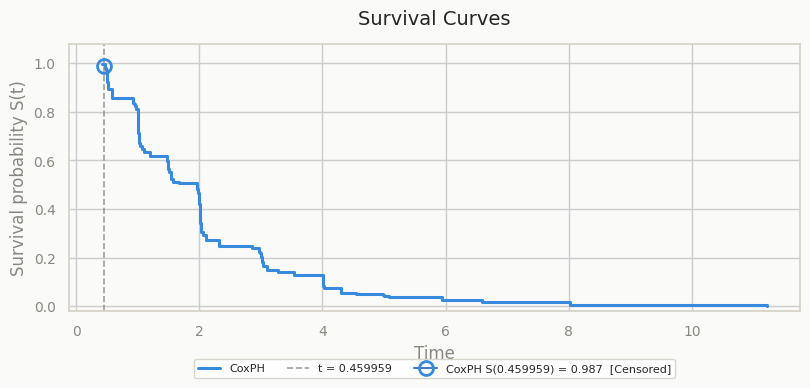

In [ ]:
from postprocessing import plot_individual_survival_curves

i = 2
curve_cox = surv_cox_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_cox],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]), event=int(y_ev_mci_test[i]),
    labels=['CoxPH'])

In [ ]:
from postprocessing import km_risk_quartile

cox_risk_mci = np.log(surv_cox_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(cox_risk_mci, y_ev_mci_test, y_dur_mci_test, 'CoxPH', 'MCI->AD')


---
#### Cox PH — What This Curve Shows

The individual survival curve above shows the Cox PH model's predicted $S(t \mid x)$
for a single test subject. The step-function shape is characteristic of Cox PH's
non-parametric baseline hazard: the curve drops at each observed event time in the
training data.

**Coefficient interpretation:** High positive `beta` on a feature (e.g., APOE4,
high CSF TAU, or negative hippocampal slope) increases the predicted hazard,
pulling the survival curve down faster. High negative `beta` (e.g., high MMSE,
large hippocampal volume) is protective.

**Train/OOF gap check:** If the printed gap (`train_C - OOF_C`) exceeds ~0.06,
consider increasing the `penalizer` bound in the HPO search space or raising
`l1_ratio` toward 0.5 to apply more sparsity.


### 6.2 Gradient Boosting Survival Analysis (GBSA)

GBSA is a tree-based survival model from `scikit-survival` that fits an additive
ensemble of regression trees to the negative gradient of the Cox partial log-likelihood:

$$\mathcal{L}(\beta) = \sum_i \left[ x_i^\top \beta - \log\left( \sum_{j:\, t_j \geq t_i} \exp(x_j^\top \beta) \right) \right]$$

Each boosting iteration approximates the log-risk function with a shallow regression tree,
accumulating non-linear feature interactions that the linear Cox model cannot capture.
Unlike DeepSurv, GBSA is tree-based and does not require feature standardization or GPU
acceleration. Unlike Cox PH, it is invariant to monotonic feature transformations.

**HPO search space** (Optuna, 40 trials, 5-fold CV, Antolini C-td objective):

| Parameter | Range |
|-----------|-------|
| `learning_rate` | [0.005, 0.20] log-uniform |
| `n_estimators` | [100, 800] step 50 |
| `max_depth` | [1, 6] |
| `min_samples_split` | [2, 30] |
| `min_samples_leaf` | [1, 30] |
| `max_features` | [0.3, 1.0] |
| `subsample` | [0.5, 1.0] |

**Overfitting diagnostics:** OOF C-td and in-sample C-td are both reported.
A gap > 0.06–0.08 suggests the trees are memorizing training structure and warrants
lower `max_depth` or higher `min_samples_leaf`.

| Output | Variable |
|--------|----------|
| Trained model | `gbsa_model_mci`, `gbsa_model_cn` |
| Feature importances | `imp_mci` — mean decrease in impurity, sorted descending |
| Test survival matrix | `surv_gbsa_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `c_gbsa_mci` |


  0%|          | 0/40 [00:00<?, ?it/s]

  [MCI->Dementia] GBSA best Antolini-C: 0.8261 | params: {'learning_rate': 0.03858823588916072, 'n_estimators': 400, 'max_depth': 3, 'min_samples_split': 30, 'min_samples_leaf': 8, 'max_features': 0.3374736020110355, 'subsample': 0.7506207456917255}


  0%|          | 0/40 [00:00<?, ?it/s]

  [CN->Decline] GBSA best Antolini-C: 0.7530 | params: {'learning_rate': 0.07411348667901062, 'n_estimators': 200, 'max_depth': 1, 'min_samples_split': 8, 'min_samples_leaf': 17, 'max_features': 0.9969723776143733, 'subsample': 0.6246385122073201}
  Checkpointed: gbsa_mci -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_mci.pkl
  Checkpointed: gbsa_cn -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_cn.pkl
  Checkpointed: gbsa_studies -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/gbsa_studies.pkl
  GBSA final C-td: 0.8340
  GBSA final C-td: 0.7408
GBSA  MCI→Dem: 0.8340 | CN→Dec: 0.7408


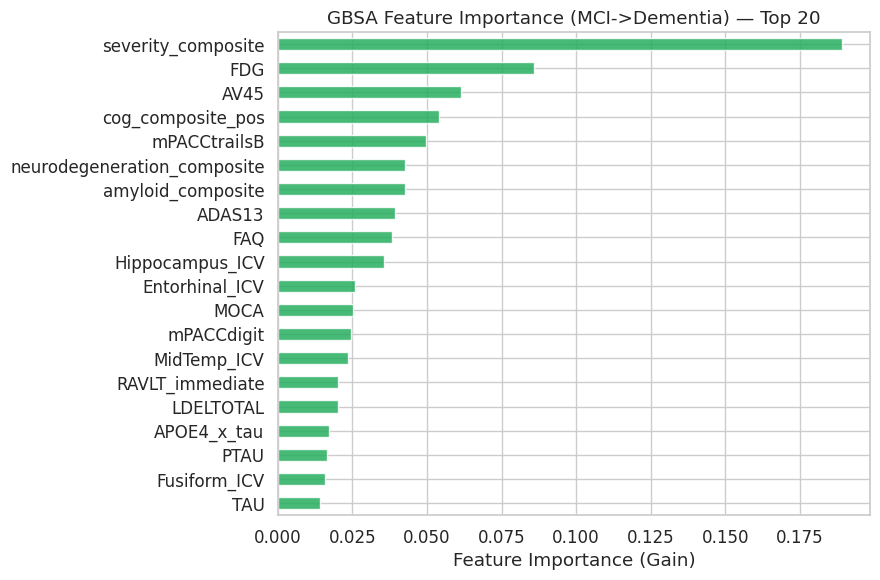

In [ ]:
from modeling import gbsa_survival_cv, calc_gbsa_c, bootstrap_cindex_td

if RETRAIN:
    # gbsa_survival_cv returns: oof_c, train_c, imp, model, study, oof_preds
    oof_c_gbsa_mci, train_c_gbsa_mci, imp_mci, gbsa_model_mci, gbsa_study_mci, _ = gbsa_survival_cv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train,
        feature_names=list(X_mci_train.columns), label='MCI->AD', n_trials=40)
    print(f'GBSA OOF C-td: {oof_c_gbsa_mci:.4f} | in-sample: {train_c_gbsa_mci:.4f} | gap: {train_c_gbsa_mci-oof_c_gbsa_mci:+.4f}')
    oof_c_gbsa_cn, train_c_gbsa_cn, imp_cn, gbsa_model_cn, gbsa_study_cn, _ = gbsa_survival_cv(
        X_cn_train, y_ev_cn_train, y_dur_cn_train,
        feature_names=list(X_cn_train.columns), label='CN->MCI or AD', n_trials=40)
    save_checkpoint('gbsa_mci', gbsa_model_mci)
    save_checkpoint('gbsa_cn',  gbsa_model_cn)
    save_checkpoint('gbsa_studies', (gbsa_study_mci, gbsa_study_cn))
else:
    gbsa_model_mci = load_checkpoint('gbsa_mci')
    gbsa_model_cn  = load_checkpoint('gbsa_cn')
    _studies = load_checkpoint('gbsa_studies')
    gbsa_study_mci, gbsa_study_cn = _studies if _studies else (None, None)
    imp_mci = pd.Series(gbsa_model_mci.feature_importances_,
                        index=list(X_mci_train.columns)).sort_values(ascending=False)
    imp_cn  = pd.Series(gbsa_model_cn.feature_importances_,
                        index=list(X_cn_train.columns)).sort_values(ascending=False)

c_td_gbsa_mci, surv_gbsa_mci = calc_gbsa_c(gbsa_model_mci, X_mci_test, y_ev_mci_test, y_dur_mci_test)
c_td_gbsa_cn,  surv_gbsa_cn  = calc_gbsa_c(gbsa_model_cn,  X_cn_test,  y_ev_cn_test,  y_dur_cn_test)

print('Computing bootstrap CIs for GBSA...')
ci_gbsa_mci = bootstrap_cindex_td(y_ev_mci_test, y_dur_mci_test, surv_gbsa_mci, n_bootstrap=500)
ci_gbsa_cn  = bootstrap_cindex_td(y_ev_cn_test,  y_dur_cn_test,  surv_gbsa_cn,  n_bootstrap=500)
results[('GBSA', 'MCI->AD')]       = (c_td_gbsa_mci, ci_gbsa_mci['lower'], ci_gbsa_mci['upper'])
results[('GBSA', 'CN->MCI or AD')] = (c_td_gbsa_cn,  ci_gbsa_cn['lower'],  ci_gbsa_cn['upper'])
print(f'GBSA MCI: {c_td_gbsa_mci:.4f}  95% CI [{ci_gbsa_mci["lower"]:.4f}, {ci_gbsa_mci["upper"]:.4f}]')
print(f'GBSA CN:  {c_td_gbsa_cn:.4f}   95% CI [{ci_gbsa_cn["lower"]:.4f}, {ci_gbsa_cn["upper"]:.4f}]')

fig, ax = plt.subplots(figsize=(9, 6))
imp_mci.head(20).sort_values().plot.barh(ax=ax, color='#27ae60', alpha=0.85)
ax.set(xlabel='Feature Importance (MDI)', title='GBSA Feature Importance (MCI->AD) -- Top 20')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gbsa_feature_importance_mci.png', dpi=150, bbox_inches='tight')
plt.show()

from postprocessing import km_risk_quartile
gbsa_risk_mci = np.log(surv_gbsa_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(gbsa_risk_mci, y_ev_mci_test, y_dur_mci_test, 'GBSA', 'MCI->AD')


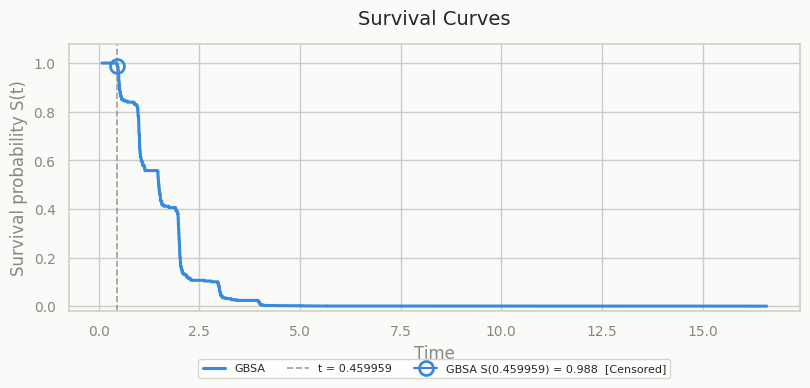

In [ ]:
from postprocessing import plot_individual_survival_curves

i = 2
curve_gbsa = surv_gbsa_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_gbsa],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]), event=int(y_ev_mci_test[i]),
    labels=['GBSA'])

---
#### GBSA — What This Curve Shows

The individual GBSA survival curve tends to be smoother than Cox PH because the
boosted ensemble's predicted cumulative hazard is evaluated on all unique event
times in the training set. GBSA can represent non-monotonic feature effects and
interactions that Cox PH cannot.

**Feature importance:** The `imp_mci` Series (mean decrease in impurity) reports
which features the ensemble splits on most often. Slope features (particularly
`slope_MMSE`, `slope_Hippocampus`) and APOE4 interaction terms typically dominate
in the MCI cohort. Tree-based importance is biased toward high-cardinality features;
use `permutation_importance_survival()` from `modeling.py` for a less biased estimate.

**Train/OOF gap check:** GBSA is prone to overfitting with deep trees. If the gap
exceeds 0.08, examine `max_depth` (best trial ≤ 3 is a good sign) and `min_samples_leaf`.


### 6.3 Weibull Accelerated Failure Time (AFT)

The Weibull AFT model is a **parametric** survival model that directly models log
survival time as a linear function of features:

$$\log T_i = \mu + \boldsymbol{\gamma}^\top x_i + \sigma \epsilon_i$$

where $T_i$ is the survival time, $\sigma$ is the scale parameter, and $\epsilon_i$
follows an extreme value distribution (inducing the Weibull marginal for $T$). Unlike
the Cox model, AFT makes a distributional assumption about event times, which enables
it to predict absolute survival times rather than only relative hazard ratios.

**Key difference from Cox PH and GBSA:** AFT models the *acceleration* of time to
event — a positive coefficient on a feature means that feature accelerates failure
(shortens survival time), while a negative coefficient decelerates it (extends survival).

**Why include it?** The Weibull AFT provides a fast-training parametric baseline
with full coefficient interpretability and p-values. It is most useful as a
sanity-check against the non-parametric models and for generating SHAP-based
feature attributions via `predict_expectation`.

**Implementation:** `lifelines.WeibullAFTFitter`, fit directly on `X_mci_train`
without Optuna HPO (parametric models have fewer hyperparameters). Evaluated with
the same IPCW adj_antolini C-td as all other models for fair comparison.

| Output | Variable |
|--------|----------|
| Trained model | `aft_model_mci` |
| Test survival matrix | `aft_surv_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `aft_c_mci` |


--- Model Summary ---


<lifelines.WeibullAFTFitter: fitted with 766 total observations, 458 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 766
number of events observed = 308
           log-likelihood = -716.05
         time fit was run = 2026-04-27 09:48:56 UTC

---
                                      coef exp(coef)   se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ ABETA                         0.00      1.00      47.30          -92.71           92.72                0.00            1.84e+40
        ADAS11                       -0.04      0.96       0.03           -0.10            0.02                0.90                1.02
        ADAS13                        0.01      1.01   47530.25       -93157.57        93157.59                0.00                 inf
        AGE                           0.03      1.03       0.03           -0.03            0.09                0.97                1.09
        APOE4                        -0.36      0.70       0.36           -1.07            0.35                0.34                1.41
        APOE4_amyloid_pos             0.02      1.02       0.19           -0.35            0.38                0.70                1.47
        APOE4_x_amyloid               0.13      1.13       0.14           -0.15            0.40                0.86                1.50
        APOE4_x_hippo_ICV            20.24  6.18e+08      79.85         -136.26          176.75                0.00            5.76e+76
        APOE4_x_tau                   0.03      1.03       0.06           -0.08            0.15                0.92                1.16
        ATN_composite                 0.02      1.02       0.08           -0.14            0.19                0.87                1.21
        AV45                         -0.71      0.49   93273.14      -182812.71       182811.29                0.00                 inf
        CDRSB                        -0.16      0.85  255569.37      -500906.92       500906.60                0.00                 inf
        EcogPtTotal                  -0.19      0.83       0.25           -0.67            0.30                0.51                1.35
        EcogSPTotal                  -0.04      0.96       0.25           -0.53            0.46                0.59                1.58
        Entorhinal_ICV              208.93  5.46e+90     122.50          -31.17          449.03                0.00           1.03e+195
        FAQ                          -0.03      0.97   74900.16      -146801.65       146801.58                0.00                 inf
        FDG                           1.94      6.98   16847.32       -33018.19        33022.08                0.00                 inf
        Fusiform_ICV                 20.25  6.23e+08      38.61          -55.42           95.92                0.00            4.56e+41
        Hippocampus_ICV             149.00  5.15e+64     115.15          -76.68          374.69                0.00           5.31e+162
        LDELTOTAL                    -0.06      0.94   32223.61       -63157.18        63157.06                0.00                 inf
        MMSE                         -0.15      0.86   65720.21      -128809.40       128809.11                0.00                 inf
        MOCA                          0.05      1.05       0.03           -0.00            0.10                1.00                1.11
        MidTemp_ICV                  38.04  3.30e+16      32.99          -26.62          102.69                0.00            3.96e+44
        PTAU                          0.01      1.01     186.86         -366.22          366.24                0.00           1.14e+159
        PTEDUCAT                      0.09      1.10       0.13           -0.17            0.35                0.85                1.4

  Checkpointed: aft_mci -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/aft_mci.pkl


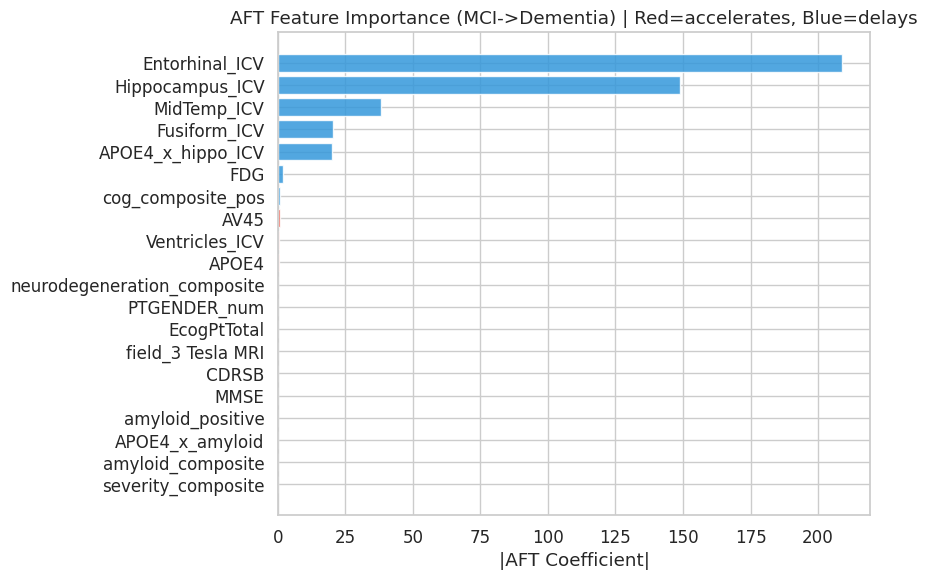

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import WeibullAFTFitter
from concordance import concordance_td
from modeling import bootstrap_cindex_td
from sklearn.model_selection import StratifiedKFold as _SKF

# 5-fold CV over penalizer strengths -- prevents L2-unregularized overfitting
_skf_aft = _SKF(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
_y_dur_tr = y_dur_mci_train.values if hasattr(y_dur_mci_train,'values') else np.array(y_dur_mci_train)
_y_ev_tr  = y_ev_mci_train.values  if hasattr(y_ev_mci_train, 'values') else np.array(y_ev_mci_train)
_data_aft_full = X_mci_train.copy()
_data_aft_full['duration'] = _y_dur_tr
_data_aft_full['event']    = _y_ev_tr

best_pen, best_c_aft = 0.0, -1.0
for pen in [0.0, 0.01, 0.1, 1.0, 5.0]:
    _fcs = []
    for tr, va in _skf_aft.split(X_mci_train, _y_ev_tr):
        _dtr = X_mci_train.iloc[tr].copy()
        _dtr['duration'] = _y_dur_tr[tr]; _dtr['event'] = _y_ev_tr[tr]
        _dva = X_mci_train.iloc[va].copy()
        _dva['duration'] = _y_dur_tr[va]; _dva['event'] = _y_ev_tr[va]
        try:
            _m = WeibullAFTFitter(penalizer=pen)
            _m.fit(_dtr, duration_col='duration', event_col='event')
            _fcs.append(_m.score(_dva, scoring_method='concordance_index'))
        except Exception: pass
    if _fcs:
        _mean = np.mean(_fcs)
        print(f'  AFT penalizer={pen:.2f}: CV C = {_mean:.4f}')
        if _mean > best_c_aft: best_c_aft, best_pen = _mean, pen
print(f'Best AFT penalizer: {best_pen}  (CV C={best_c_aft:.4f})')

aft_model_mci = WeibullAFTFitter(penalizer=best_pen)
aft_model_mci.fit(_data_aft_full, duration_col='duration', event_col='event')
print('--- AFT Model Summary ---')
aft_model_mci.print_summary()
save_checkpoint('aft_mci', aft_model_mci)

_aft_params = aft_model_mci.params_['lambda_'].drop('Intercept', errors='ignore')
_aft_imp = _aft_params.abs().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 6))
_colors_aft = ['#e74c3c' if _aft_params[f] < 0 else '#3498db' for f in _aft_imp.index]
ax.barh(_aft_imp.index[::-1], _aft_imp.values[::-1], color=_colors_aft[::-1], alpha=0.85)
ax.set(xlabel='|AFT Coefficient (lambda_)|',
       title='AFT Feature Importance (MCI->AD) | Red=shortens survival, Blue=extends')
plt.tight_layout()
plt.savefig(FIG_DIR / 'aft_feature_importance_mci.png', dpi=150, bbox_inches='tight')
plt.show()

PROFILE_SUBJECT_IDX = 2


AFT C-td MCI->Dementia: 0.8471


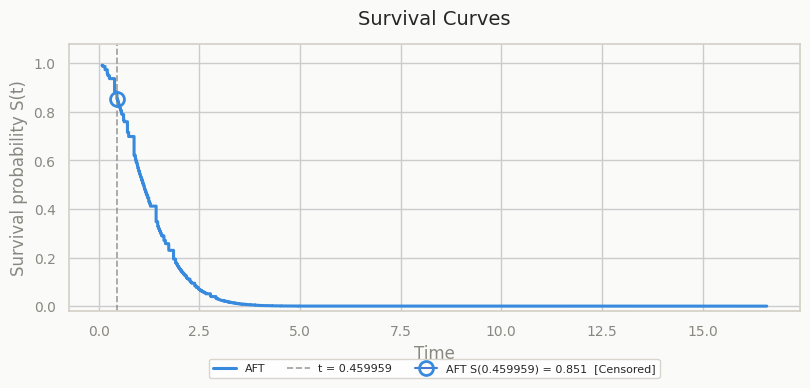

In [ ]:
subjects_aft_test = X_mci_test.copy()
_dur_arr = y_dur_mci_test.values if hasattr(y_dur_mci_test,'values') else np.array(y_dur_mci_test)
_ev_arr  = np.array(y_ev_mci_test, dtype=np.int32)
subjects_aft_test['duration'] = _dur_arr
subjects_aft_test['event']    = _ev_arr

aft_surv_mci  = aft_model_mci.predict_survival_function(subjects_aft_test)
aft_time_grid = aft_surv_mci.index.values.astype(np.float64)
aft_surv_idx  = np.clip(np.searchsorted(aft_time_grid, _dur_arr),
                        0, len(aft_time_grid)-1).astype(np.int64)
aft_c_mci = concordance_td(_dur_arr, _ev_arr, aft_surv_mci.values, aft_surv_idx,
                            method='adj_antolini', ipcw=True)

print('Computing bootstrap CI for AFT...')
ci_aft_mci = bootstrap_cindex_td(_ev_arr, _dur_arr, aft_surv_mci, n_bootstrap=500)
results[('AFT', 'MCI->AD')] = (aft_c_mci, ci_aft_mci['lower'], ci_aft_mci['upper'])
print(f'AFT C-td MCI->AD: {aft_c_mci:.4f}  95% CI [{ci_aft_mci["lower"]:.4f}, {ci_aft_mci["upper"]:.4f}]')

curve_aft = aft_surv_mci.iloc[:, PROFILE_SUBJECT_IDX]
plot_individual_survival_curves(
    curves=[curve_aft],
    duration=float(_dur_arr[PROFILE_SUBJECT_IDX]),
    event=int(_ev_arr[PROFILE_SUBJECT_IDX]),
    labels=['AFT'])

from postprocessing import km_risk_quartile
aft_risk_mci = np.log(aft_surv_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(aft_risk_mci, _ev_arr, _dur_arr, 'AFT', 'MCI->AD')


  0%|          | 0/100 [00:00<?, ?it/s]

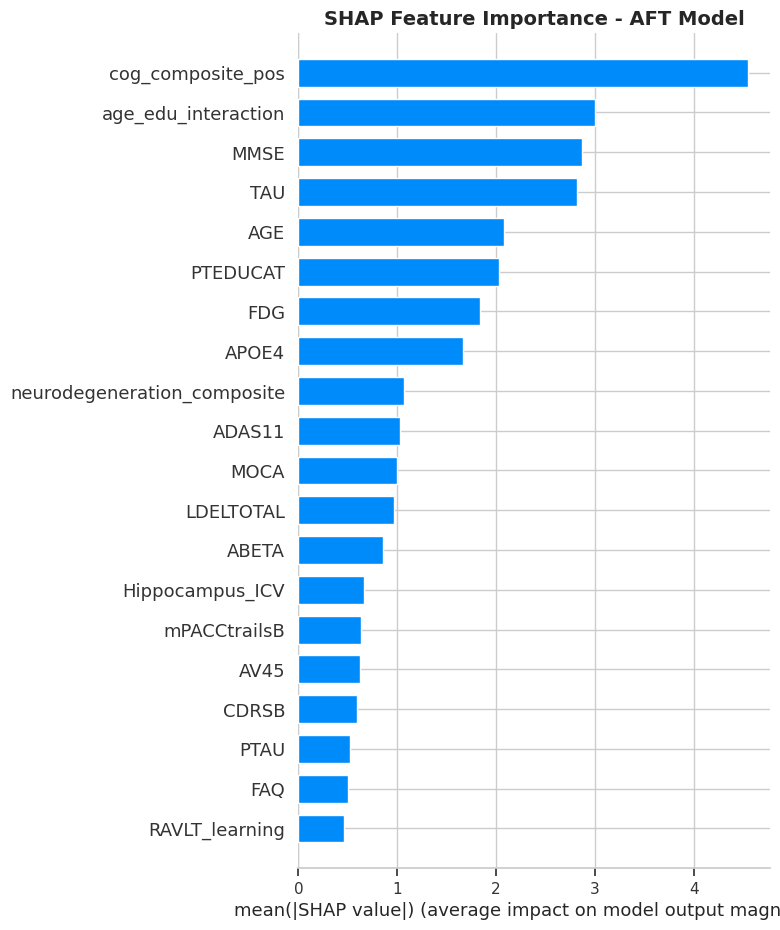

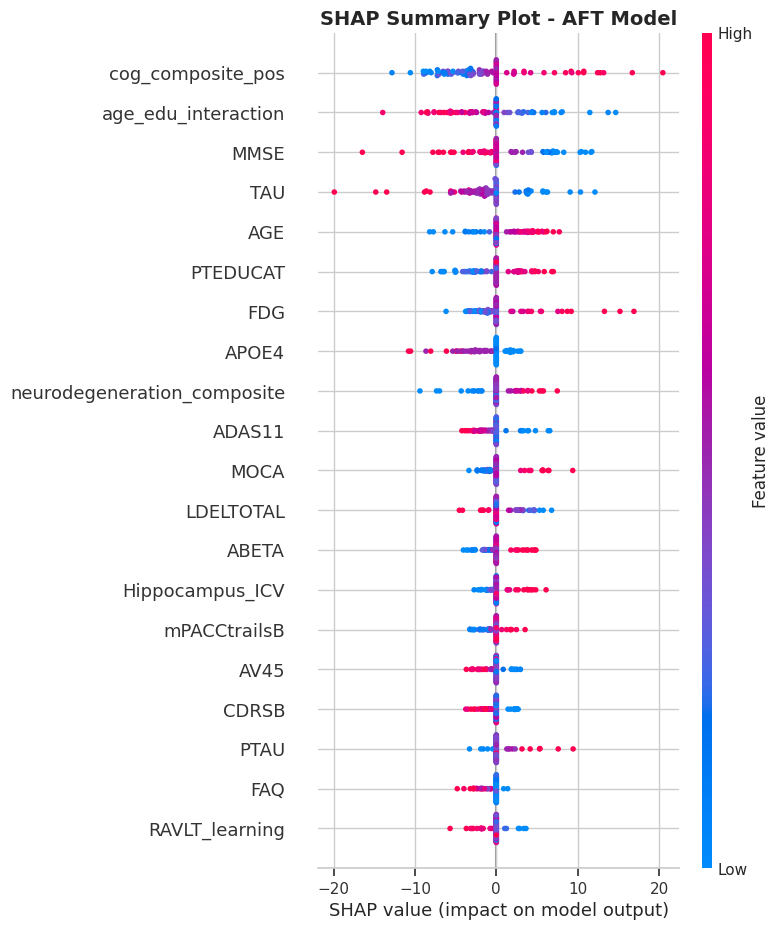

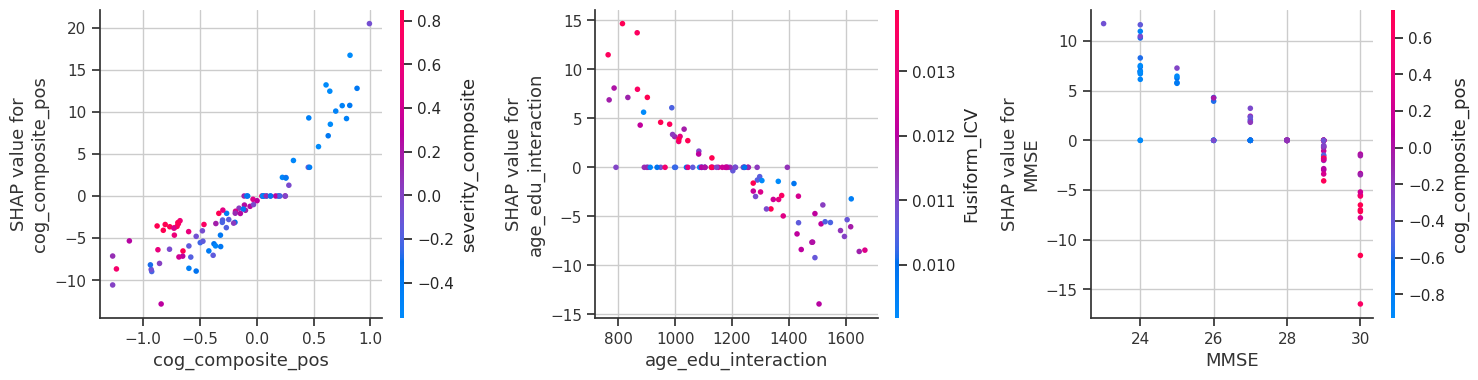

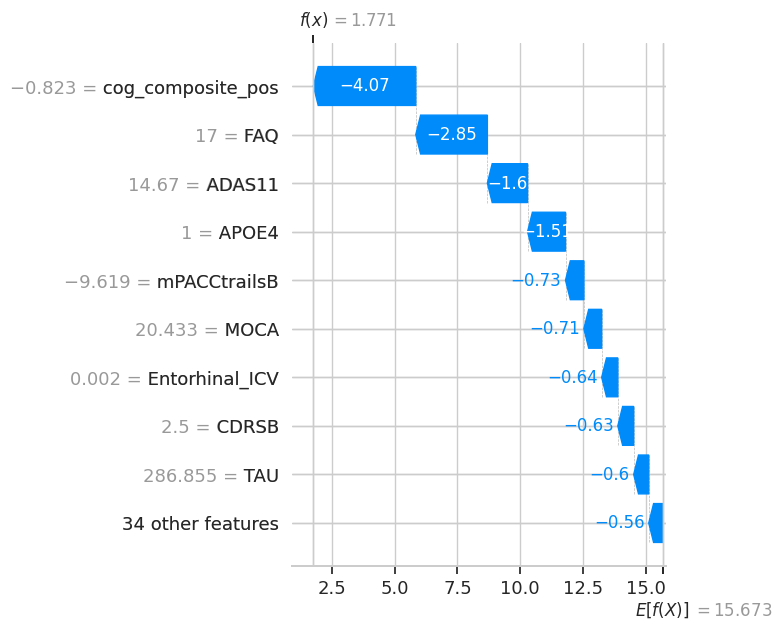


Feature Importance Rankings:
                        Feature  Mean_Abs_SHAP  Mean_SHAP
15            cog_composite_pos       4.548184  -1.227798
3           age_edu_interaction       3.004564  -0.445857
5                          MMSE       2.866592   0.665385
24                          TAU       2.817654  -1.059155
0                           AGE       2.076680   1.056517
2                      PTEDUCAT       2.025266  -0.266210
26                          FDG       1.840695   0.404469
4                         APOE4       1.667662  -1.062277
29  neurodegeneration_composite       1.070107   0.165791
7                        ADAS11       1.027261  -0.301978
14                         MOCA       0.992386   0.203578
9                     LDELTOTAL       0.970618   0.618451
23                        ABETA       0.851380  -0.004720
17              Hippocampus_ICV       0.658670   0.227351
40                 mPACCtrailsB       0.636076  -0.370338
27                         AV45       0.62

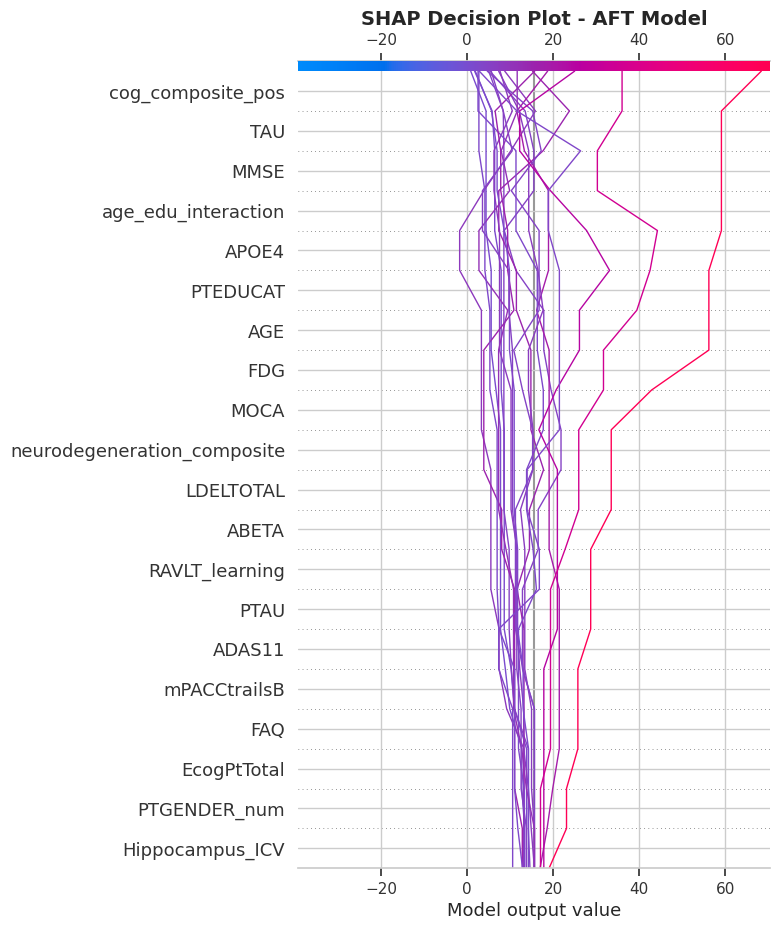


SHAP analysis complete!
Expected value (baseline prediction): 15.6733

All plots saved to current directory


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lifelines.utils import concordance_index

# Assuming you have already trained your aft_model_mci
# and have X_mci_train and X_mci_test available

# Create a wrapper function for SHAP
# AFT models predict log time, so we'll create a prediction function
def model_predict(X):
    """
    Wrapper function for SHAP to get predictions from the AFT model
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_mci_train.columns)
    return aft_model_mci.predict_expectation(X).values

# Initialize SHAP explainer
# Using KernelExplainer for model-agnostic explanation
explainer = shap.KernelExplainer(model_predict, X_mci_train.sample(100, random_state=42))

# Calculate SHAP values for test set (or a sample if too large)
# Using a sample to speed up computation
sample_size = min(100, len(X_mci_test))
X_test_sample = X_mci_test.sample(sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 1. Summary Plot (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - AFT Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Summary Plot (Detailed with feature values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - AFT Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Dependence plots for top features
# Get top 3 most important features
feature_importance = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(feature_importance)[-3:][::-1]
top_features = X_test_sample.columns[top_features_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, feature_idx in enumerate(top_features_idx):
    shap.dependence_plot(
        feature_idx,
        shap_values,
        X_test_sample,
        show=False,
        ax=axes[idx]
    )
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Force plot for individual predictions
# Show force plot for first observation
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_sample.iloc[0]
)
shap.save_html('shap_force_plot_sample.html', force_plot)

# 5. Waterfall plot for individual prediction
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[0].values,
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Create a feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0),
    'Mean_SHAP': shap_values.mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("\nFeature Importance Rankings:")
print(feature_importance_df)

# Save feature importance
feature_importance_df.to_csv('shap_feature_importance.csv', index=False)

# 7. Decision plot for multiple observations
plt.figure(figsize=(10, 8))
shap.decision_plot(
    explainer.expected_value,
    shap_values[:20],  # First 20 samples
    X_test_sample.iloc[:20],
    show=False
)
plt.title("SHAP Decision Plot - AFT Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSHAP analysis complete!")
print(f"Expected value (baseline prediction): {explainer.expected_value:.4f}")
print(f"\nAll plots saved to current directory")

### 6.4 DeepSurv — Neural Cox Proportional Hazards

DeepSurv replaces the linear log-risk term $\boldsymbol{\beta}^\top x$ in Cox PH
with a multilayer perceptron (MLP), learning a non-linear risk representation:

$$h(t \mid x) = h_0(t) \cdot \exp(f_\theta(x))$$

where $f_\theta$ is trained by backpropagating the Cox partial log-likelihood.
This captures complex feature interactions and non-monotonic relationships that
the linear Cox model cannot represent, at the cost of interpretability.

**Architecture:** Fully connected layers with ReLU activations, batch normalization,
dropout, and a single linear output node. Input features are standardized to zero
mean and unit variance via `StandardScaler` (fitted on the training split only to
prevent leakage of validation statistics).

**HPO search space** (Optuna, 25 trials, 5-fold CV, C-td objective):

| Parameter | Options / Range |
|-----------|----------------|
| Architecture | 6 MLP options: `[32,32]` to `[256,256,128]` |
| `dropout` | [0.05, 0.50] uniform |
| `lr` (learning rate) | [5e-5, 5e-2] log-uniform |
| `wd` (weight decay / L2) | [1e-5, 1e-2] log-uniform |
| `batch_size` | {32, 64, 128, 256} |

**Overfitting safeguards:** Early stopping (`patience=10`) per CV fold; dropout and
weight decay jointly tuned; scaler fitted only on training fold in each split.
Final model uses an 80/20 stratified split with `patience=15`.

| Output | Variable |
|--------|----------|
| Trained model | `ds_model_mci` (PycoxCoxPH with baseline hazards computed) |
| Feature scaler | `ds_scaler_mci` |
| Training loss history | `ds_loss_mci` — `{'train': [...], 'val': [...]}` |
| Test survival matrix | `surv_mci` — shape `(n_times × n_test_subjects)` |
| Test C-td | `ds_c_mci` |


LightGBM device: cpu
Training DeepSurv — MCI cohort...


  0%|          | 0/25 [00:00<?, ?it/s]

  [MCI->Dementia] DeepSurv best C-td: 0.8214 | {'arch_idx': 5, 'dropout': 0.4238872353178843, 'lr': 0.040437058887213995, 'wd': 1.0788661515919544e-05, 'batch': 256}
  Checkpointed: deepsurv_mci_metadata -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/deepsurv_mci_metadata.pkl
  Checkpointed: deepsurv_studies -> /content/alzheimer-prediction/Modeling on the Tabular dataset/checkpoints/deepsurv_studies.pkl
  DeepSurv final C-td: 0.8480
DeepSurv  MCI->Dem: 0.8480


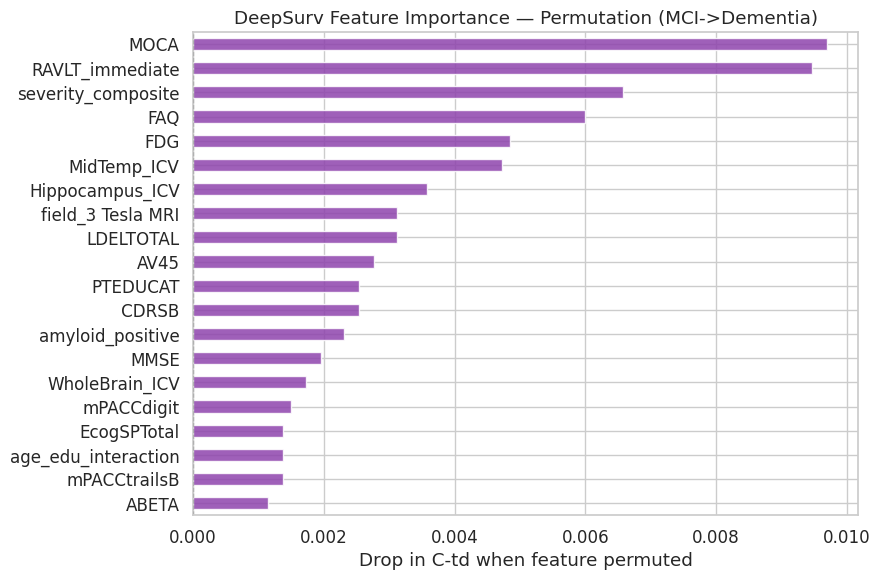

In [ ]:
import importlib, modeling
importlib.reload(modeling)
from modeling import run_deepsurv, calc_deepsurv_c, bootstrap_cindex_td

if RETRAIN:
    print('Training DeepSurv -- MCI cohort...')
    # run_deepsurv returns: oof_c, train_c, model, scaler, loss_history, study, oof_preds
    oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci, ds_study_mci, _ = run_deepsurv(
        X_mci_train, y_ev_mci_train, y_dur_mci_train, 'MCI->AD', n_trials=25)
    print(f'DeepSurv OOF C-td: {oof_c_ds_mci:.4f} | in-sample: {train_c_ds_mci:.4f} | gap: {train_c_ds_mci-oof_c_ds_mci:+.4f}')
    ds_model_mci.callbacks = []
    save_checkpoint('deepsurv_mci_metadata',
                    (oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci))
    save_checkpoint('deepsurv_studies', ds_study_mci)
else:
    _ck = load_checkpoint('deepsurv_mci_metadata')
    oof_c_ds_mci, train_c_ds_mci, ds_model_mci, ds_scaler_mci, ds_loss_mci = _ck
    ds_model_mci.compute_baseline_hazards()
    ds_study_mci = load_checkpoint('deepsurv_studies')

ds_c_mci, surv_mci = calc_deepsurv_c(
    ds_model_mci, ds_scaler_mci, X_mci_test, y_ev_mci_test, y_dur_mci_test)

print('Computing bootstrap CI for DeepSurv...')
ci_ds_mci = bootstrap_cindex_td(y_ev_mci_test, y_dur_mci_test, surv_mci, n_bootstrap=500)
results[('DeepSurv', 'MCI->AD')] = (ds_c_mci, ci_ds_mci['lower'], ci_ds_mci['upper'])
print(f'DeepSurv MCI->AD: {ds_c_mci:.4f}  95% CI [{ci_ds_mci["lower"]:.4f}, {ci_ds_mci["upper"]:.4f}]')

# Permutation feature importance on test set
from pycox.evaluation import EvalSurv as _ES
_X_ts = ds_scaler_mci.transform(X_mci_test.values).astype('float32')
_base_surv = ds_model_mci.predict_surv_df(_X_ts)
_base_c = _ES(_base_surv, np.array(y_dur_mci_test, dtype=np.float64),
              np.array(y_ev_mci_test, dtype=bool)).concordance_td()
_rng = np.random.default_rng(RANDOM_SEED)
_perm_drops = {}
for _j, _feat in enumerate(X_mci_test.columns):
    _Xp = _X_ts.copy()
    _Xp[:, _j] = _rng.permutation(_Xp[:, _j])
    _sp = ds_model_mci.predict_surv_df(_Xp)
    _perm_drops[_feat] = _base_c - _ES(
        _sp, np.array(y_dur_mci_test, dtype=np.float64),
        np.array(y_ev_mci_test, dtype=bool)).concordance_td()
ds_imp = pd.Series(_perm_drops).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 6))
ds_imp.head(20).sort_values().plot.barh(ax=ax, color='#8e44ad', alpha=0.85)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set(xlabel='Drop in C-td when feature permuted',
       title='DeepSurv Permutation Importance -- Top 20 (MCI->AD)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'deepsurv_feature_importance_mci.png', dpi=150, bbox_inches='tight')
plt.show()


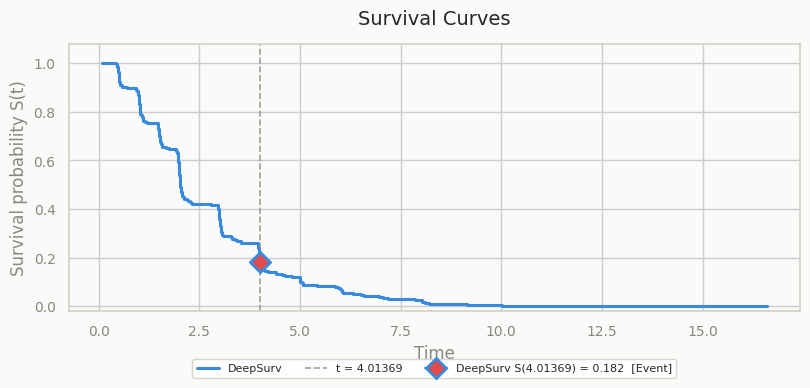

In [ ]:
from postprocessing import plot_individual_survival_curves, km_risk_quartile

i = 2
curve_ds = surv_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_ds],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test,'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['DeepSurv'])

ds_risk_mci = np.log(surv_mci.values + 1e-9).mean(axis=0) * -1
km_risk_quartile(ds_risk_mci, y_ev_mci_test, y_dur_mci_test, 'DeepSurv', 'MCI->AD')


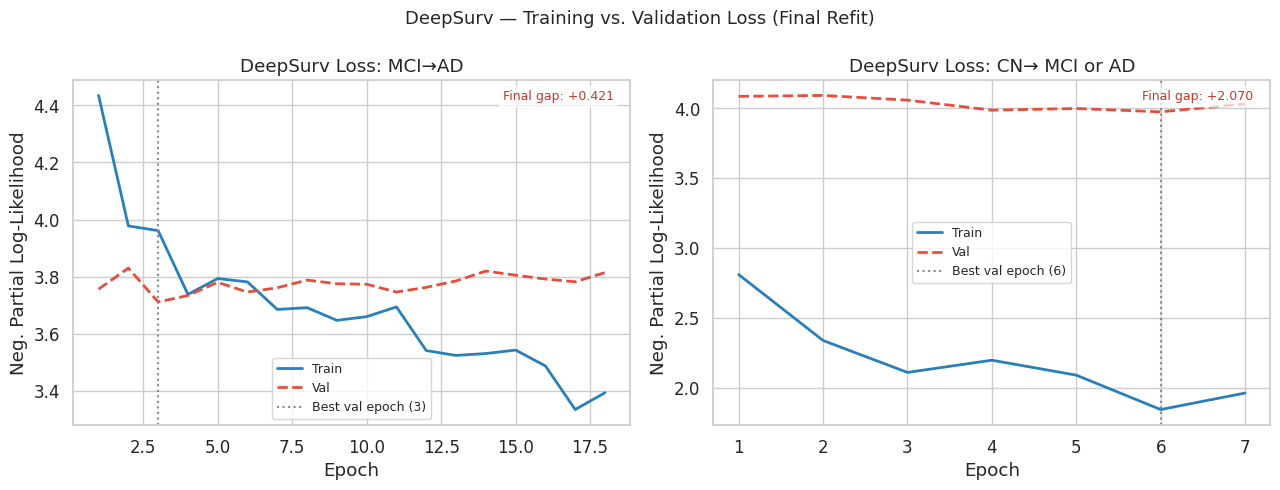

In [ ]:
def plot_deepsurv_loss(loss_dict, label, ax):
    """Plot per-epoch train/val negative partial log-likelihood."""
    train_loss = loss_dict.get('train', []) if isinstance(loss_dict, dict) else []
    val_loss   = loss_dict.get('val',   []) if isinstance(loss_dict, dict) else []
    if not train_loss:
        ax.text(0.5, 0.5, 'Loss history unavailable\n(checkpoint loaded)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(f'DeepSurv Loss: {label}')
        return
    epochs = np.arange(1, len(train_loss) + 1)
    ax.plot(epochs, train_loss, color='#2980b9', lw=2, label='Train')
    ax.plot(epochs, val_loss,   color='#e74c3c', lw=2, ls='--', label='Val')
    best_ep = int(np.argmin(val_loss)) + 1
    ax.axvline(best_ep, color='#7f8c8d', ls=':', lw=1.5, label=f'Best val epoch ({best_ep})')
    gap = val_loss[-1] - train_loss[-1]
    gap_color = '#c0392b' if gap > 0.05 else '#27ae60'
    ax.text(0.97, 0.97, f'Final gap: {gap:+.3f}', ha='right', va='top',
            transform=ax.transAxes, fontsize=9, color=gap_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set(xlabel='Epoch', ylabel='Neg. Partial Log-Likelihood',
           title=f'DeepSurv Loss: {label}')
    ax.legend(fontsize=9)

# DeepSurv only trained for MCI cohort -- single panel
fig, ax = plt.subplots(figsize=(8, 5))
plot_deepsurv_loss(ds_loss_mci, 'MCI->AD', ax)
plt.suptitle('DeepSurv -- Training vs. Validation Loss', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'deepsurv_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
#### DeepSurv — What the Loss Curves Show

The per-epoch training and validation loss curves (negative partial log-likelihood)
from the final DeepSurv refit are plotted above. Well-behaved training shows:

- Both curves **decreasing** in early epochs as the network learns
- The validation curve **flattening or diverging** from training curve at the
  point where early stopping fires — confirming the callback is working
- **No sustained upward drift** in validation loss after the minimum (which would
  indicate the network has memorized training data)

**Train/OOF gap check:** DeepSurv is the most flexible model and therefore the
most prone to overfitting with small datasets. If the OOF C-td is substantially
lower than the Optuna HPO objective (which evaluates on validation folds separately
from the final refit), the final refit may be overfitting to the full training set.
A persistent gap > 0.07 suggests increasing `dropout` bounds or weight decay in HPO.


In [ ]:
"""
Two panels per model × cohort:

  Left  — Optimization history: scatter of every trial's CV C-td plus the
           running best (red line). A still-rising best curve at trial N
           suggests increasing n_trials. A flat curve after ~10 trials
           indicates the search space is saturated.

  Right — Hyperparameter importance (fANOVA): fraction of C-td variance
           explained by each parameter. Dominance by a single param (e.g. 'lr')
           signals the others are at appropriate defaults or the space is too
           narrow to matter.
"""

def plot_optuna_diagnostics(study, model_name, cohort_label, fig_dir):
    if study is None:
        print(f'  [{model_name} | {cohort_label}] Study not available '
              f'(loaded from checkpoint without study object).')
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Optimization history ——————————————————————————————————————————————————
    ax = axes[0]
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.scatter(range(len(values)), values,
               alpha=0.45, s=22, color='#95a5a6', label='Trial C-td', zorder=2)
    ax.plot(range(len(best_so_far)), best_so_far,
            color='#e74c3c', lw=2, label='Best so far', zorder=3)
    ax.axhline(values[0], color='#bdc3c7', ls=':', lw=1)   # baseline (trial 0)
    ax.set(xlabel='Trial', ylabel='CV C-td (Antolini)',
           title=f'{model_name} [{cohort_label}] — Optimisation History')
    ax.legend(fontsize=9)

    # — Hyperparameter importance (fANOVA) ————————————————————————————————————
    ax2 = axes[1]
    try:
        importances = optuna.importance.get_param_importances(study)
        # Top 8 params by importance
        top_params = list(importances.keys())[:8]
        top_vals   = [importances[p] for p in top_params]
        colors = ['#3498db' if v == max(top_vals) else '#85c1e9' for v in top_vals]
        ax2.barh(top_params[::-1], top_vals[::-1], color=colors[::-1], alpha=0.9)
        ax2.set(xlabel='Importance (fANOVA fraction)',
                title=f'{model_name} [{cohort_label}] — Param Importance')
        ax2.axvline(0, color='black', lw=0.5)
    except Exception as e:
        ax2.text(0.5, 0.5,
                 f'Importance unavailable\n({e})',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=10, color='gray')

    plt.tight_layout()
    tag = f'{model_name.lower().replace(" ", "_")}_{cohort_label[:3].lower()}'
    plt.savefig(fig_dir / f'optuna_diag_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

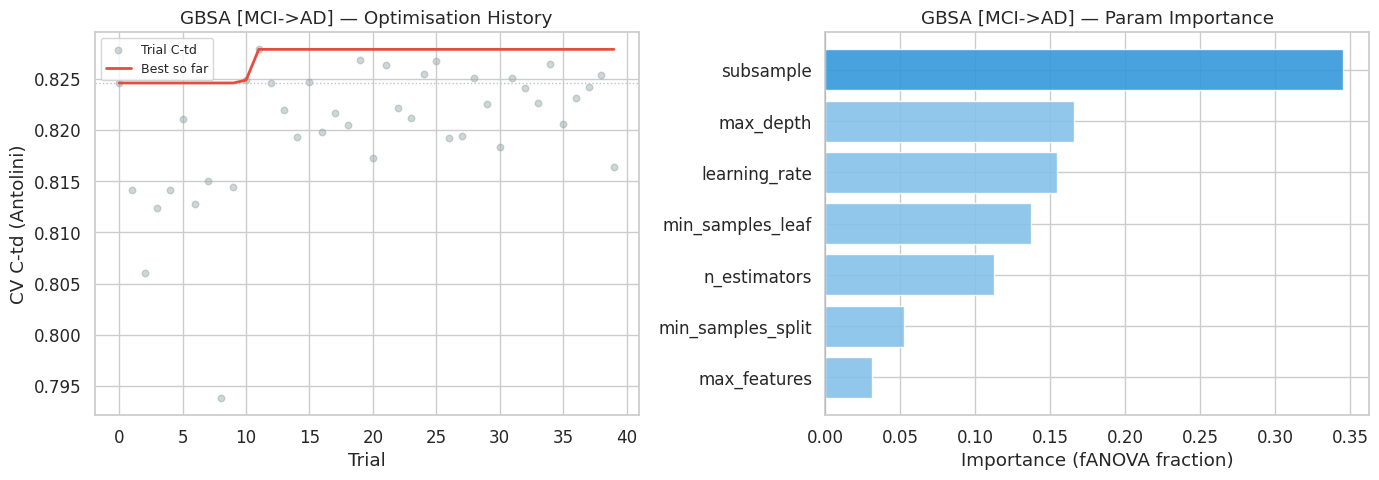

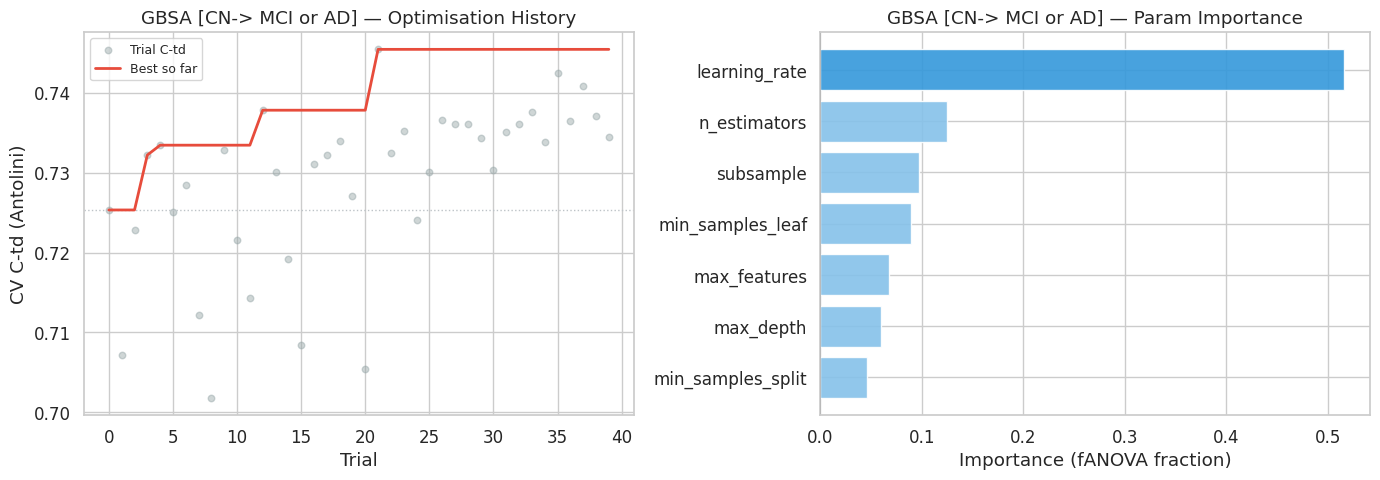

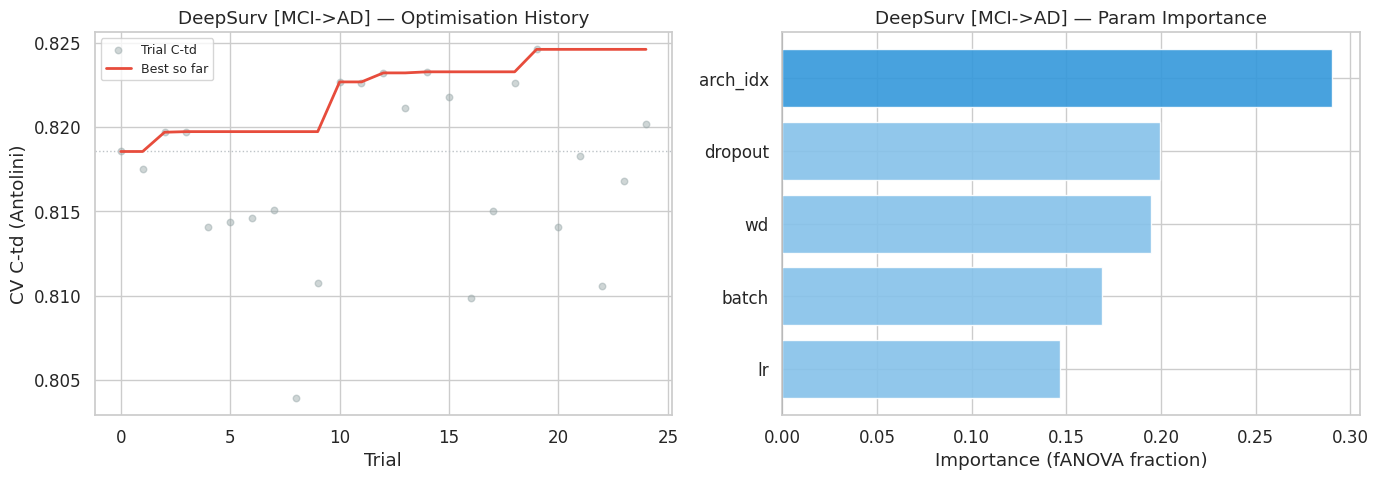

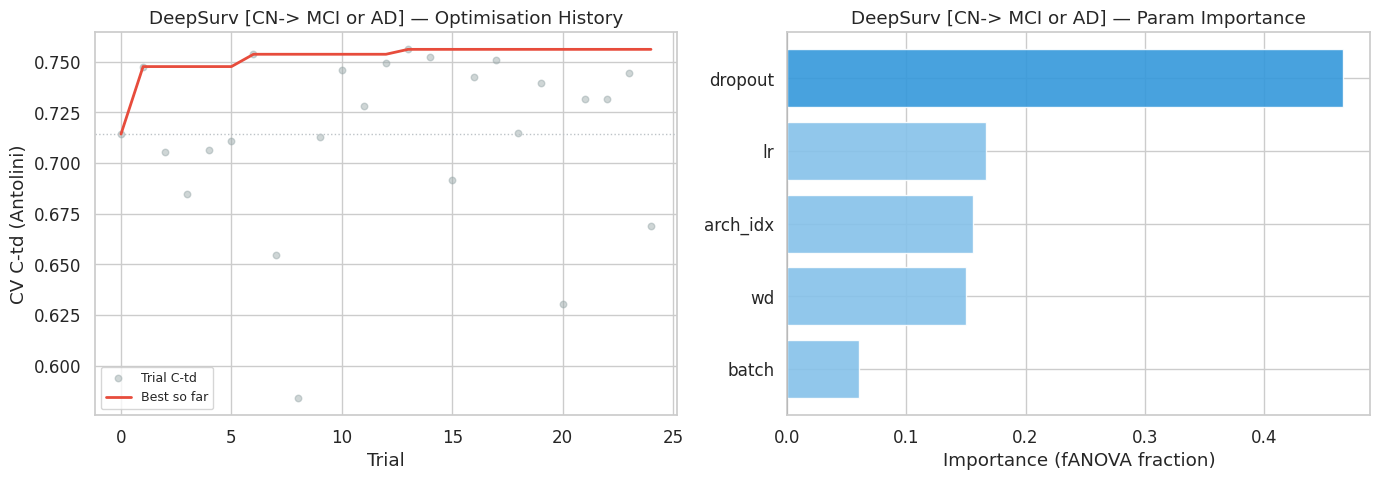

In [ ]:
# GBSA
plot_optuna_diagnostics(gbsa_study_mci, 'GBSA', 'MCI->AD', FIG_DIR)
plot_optuna_diagnostics(gbsa_study_cn,  'GBSA', 'CN-> MCI or AD',   FIG_DIR)

# DeepSurv
plot_optuna_diagnostics(ds_study_mci, 'DeepSurv', 'MCI->AD', FIG_DIR)
plot_optuna_diagnostics(ds_study_cn,  'DeepSurv', 'CN-> MCI or AD',   FIG_DIR)


### 6.5 Individual Survival Curve Comparison

Plots the full predicted survival function $S(t \mid x)$ from all four models
overlaid for a single held-out subject. The vertical dashed line marks the subject's
actual observed duration; the marker shape indicates whether the event was observed
(◆ diamond) or censored (○ open circle).

**What to look for:**
- Models that agree on the general shape of the survival curve add corroborating evidence
- Large disagreements in predicted survival probability at the subject's event time
  indicate models have learned different risk signals
- A model whose $S(t)$ is high at the event time (close to 1.0 when the event occurs)
  indicates poor calibration for that subject
- The ensemble (Section 6.6) should generally track between the individual curves


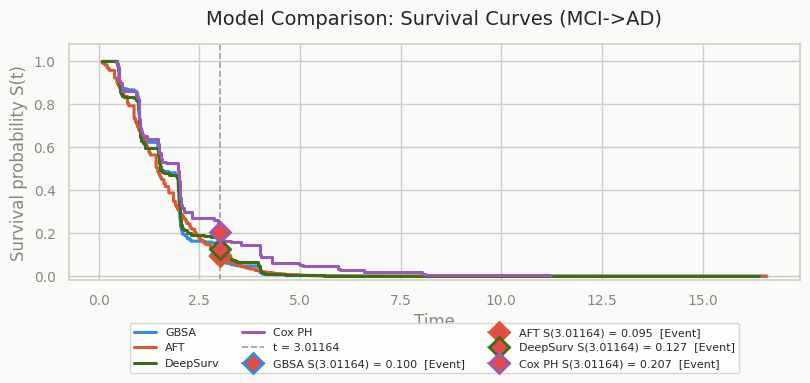

In [ ]:
from postprocessing import plot_individual_survival_curves

i = 26
plot_individual_survival_curves(
    curves=[
        surv_gbsa_mci.iloc[:, i],
        aft_surv_mci.iloc[:, i],
        surv_mci.iloc[:, i],
        surv_cox_mci.iloc[:, i],
    ],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['GBSA', 'AFT', 'DeepSurv', 'Cox PH'],
    title='Model Comparison: Survival Curves (MCI->AD)')

### 6.6 Weighted Ensemble

Combines the full predicted survival matrices from Cox PH, GBSA, Weibull AFT, and
DeepSurv using `weighted_ensemble_td()`, which blends $S(t \mid x)$ directly rather
than scalar risk scores — preserving time-resolution in the combined prediction.

**Alignment:** Survival matrices from different models may be evaluated on different
time grids. They are reindexed to a **union time grid**, then interpolated and
forward/backward-filled before blending.

**Optimization:** Optuna searches over per-model weights in [0, 1] (normalized to
sum to 1) to maximize the IPCW Antolini C-td. Because weights are optimized on the
**training set**, no test-set information is used in weight selection. Weights near
zero identify redundant models; a model contributing unique signal will receive
meaningful weight even if its individual C-td is lower.

$$S_{\text{ens}}(t \mid x) = \sum_{m} w_m \cdot S_m(t \mid x), \quad \sum_m w_m = 1$$

**Why ensemble?** The four models represent distinct inductive biases: linear
(Cox), tree-based (GBSA), parametric (AFT), and neural (DeepSurv). Errors that
are idiosyncratic to one model family are unlikely to be shared across all four,
so a weighted average tends to reduce variance in the final risk ranking.


In [ ]:
aft_surv_mci.columns = range(len(aft_surv_mci.columns))
aft_surv_mci.columns = range(len(aft_surv_mci.columns))

In [ ]:
from modeling import weighted_ensemble_td, bootstrap_cindex_td
import numpy as _np
import pandas as _pd

# Build training-set survival matrices (no test data used for weight optimisation)
_X_cox_tr = _pd.DataFrame(cox_scaler_mci.transform(X_mci_train_cox.values),
                          columns=X_mci_train_cox.columns)
_tg_tr = _np.sort(_np.unique(y_dur_mci_train[y_ev_mci_train == 1])).astype(_np.float64)
_surv_cox_tr = cox_model_mci.predict_survival_function(
    _X_cox_tr.reset_index(drop=True), times=_tg_tr)
_surv_cox_tr.index = _tg_tr
_surv_cox_tr.columns = range(len(_X_cox_tr))
_surv_cox_tr = _surv_cox_tr.clip(0.0, 1.0)

_sf_gbsa_tr = gbsa_model_mci.predict_survival_function(X_mci_train)
_tg_gbsa = _sf_gbsa_tr[0].x
_surv_gbsa_tr = _pd.DataFrame(
    _np.row_stack([fn(_tg_gbsa) for fn in _sf_gbsa_tr]).T, index=_tg_gbsa)

_aft_tr_df = X_mci_train.copy()
_aft_tr_df['duration'] = y_dur_mci_train
_aft_tr_df['event']    = y_ev_mci_train
_surv_aft_tr = aft_model_mci.predict_survival_function(_aft_tr_df)
_surv_aft_tr.columns = range(len(X_mci_train))

_X_ds_tr = ds_scaler_mci.transform(X_mci_train.values).astype('float32')
_surv_ds_tr = ds_model_mci.predict_surv_df(_X_ds_tr)

_, _, ens_weights_mci = weighted_ensemble_td(
    {'CoxPH': _surv_cox_tr, 'AFT': _surv_aft_tr,
     'GBSA': _surv_gbsa_tr, 'DeepSurv': _surv_ds_tr},
    y_ev_mci_train, y_dur_mci_train, label='MCI->AD weight tuning')
print(f'Optimized weights: {ens_weights_mci}')

_test_surfs = {'CoxPH': surv_cox_mci, 'AFT': aft_surv_mci,
               'GBSA': surv_gbsa_mci, 'DeepSurv': surv_mci}
_names = list(_test_surfs.keys())
_union_idx = _test_surfs[_names[0]].index
for _n in _names[1:]: _union_idx = _union_idx.union(_test_surfs[_n].index)
_union_idx = _union_idx.sort_values()
_normed_test = []
for _n in _names:
    _r = (_test_surfs[_n].reindex(_union_idx)
           .interpolate(method='index', axis=0, limit_area='inside')
           .ffill(axis=0).bfill(axis=0).clip(0.0, 1.0))
    _normed_test.append(_r)
ens_scores_mci = sum(ens_weights_mci[_n] * _normed_test[_i]
                     for _i, _n in enumerate(_names))

_tp = _union_idx.to_numpy()
_sidx = _np.clip(_np.searchsorted(_tp, y_dur_mci_test, side='right') - 1,
                 0, len(_tp)-1).astype(_np.int64)
from concordance import concordance_td
ens_c_mci = concordance_td(
    _np.array(y_dur_mci_test, dtype=_np.float64),
    _np.array(y_ev_mci_test,  dtype=_np.int32),
    ens_scores_mci.values, _sidx, method='adj_antolini', ipcw=True)

print('Computing bootstrap CI for Ensemble...')
ci_ens_mci = bootstrap_cindex_td(
    y_ev_mci_test, y_dur_mci_test, ens_scores_mci, n_bootstrap=500)
results[('Weighted Ensemble', 'MCI->AD')] = (
    ens_c_mci, ci_ens_mci['lower'], ci_ens_mci['upper'])
print(f'Ensemble C-td: {ens_c_mci:.4f}  '
      f'95% CI [{ci_ens_mci["lower"]:.4f}, {ci_ens_mci["upper"]:.4f}]')


  0%|          | 0/50 [00:00<?, ?it/s]

  [MCI->Dementia weight tuning] Optimized ensemble C-index: 0.8798 | weights: {'CoxPH': 0.04217262300649618, 'AFT': 0.04852494439497788, 'GBSA': 0.8192654268266533, 'DeepSurv': 0.0900370049500317}
Optimized weights: {'CoxPH': 0.04217262300649618, 'AFT': 0.04852494439497788, 'GBSA': 0.8192654268266533, 'DeepSurv': 0.0900370049500317}
Ensemble C-td MCI->Dementia: 0.8414


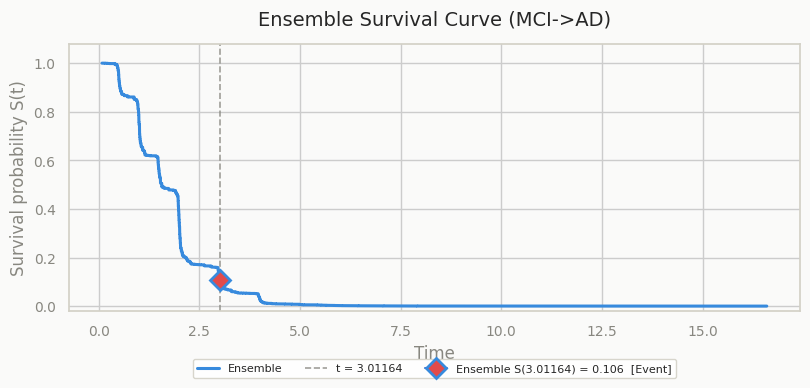

In [ ]:
i = 26
curve_ens = ens_scores_mci.iloc[:, i]
plot_individual_survival_curves(
    curves=[curve_ens],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=['Ensemble'],
    title='Ensemble Survival Curve (MCI->AD)')

In [ ]:
# Equal-weight ensemble (comparison only -- does NOT update results)
# If ens_c_mci >> c_equal the Optuna weights are adding real value.
from concordance import concordance_td as _ctd_eq
import numpy as _npeq

_ts2 = {'CoxPH': surv_cox_mci, 'AFT': aft_surv_mci,
        'GBSA': surv_gbsa_mci, 'DeepSurv': surv_mci}
_nm2 = list(_ts2.keys())
_ui2 = _ts2[_nm2[0]].index
for _n2 in _nm2[1:]: _ui2 = _ui2.union(_ts2[_n2].index)
_ui2 = _ui2.sort_values()
_nr2 = [(_ts2[_n2].reindex(_ui2)
          .interpolate(method='index', axis=0, limit_area='inside')
          .ffill(axis=0).bfill(axis=0).clip(0.0, 1.0)) for _n2 in _nm2]
_ens_eq = sum(_r2 / len(_nm2) for _r2 in _nr2)
_tp2 = _ui2.to_numpy()
_si2 = _npeq.clip(_npeq.searchsorted(_tp2, y_dur_mci_test, side='right') - 1,
                  0, len(_tp2)-1).astype(_npeq.int64)
c_equal = _ctd_eq(
    _npeq.array(y_dur_mci_test, dtype=_npeq.float64),
    _npeq.array(y_ev_mci_test,  dtype=_npeq.int32),
    _ens_eq.values, _si2, method='adj_antolini', ipcw=True)
print(f'Equal-weight ensemble C-td:    {c_equal:.4f}  (comparison only)')
print(f'Optuna-weighted ensemble C-td: {ens_c_mci:.4f}  (used in results)')
print(f'Improvement from weight opt:   {ens_c_mci - c_equal:+.4f}')


Equal-weight ensemble C-td: 0.8517


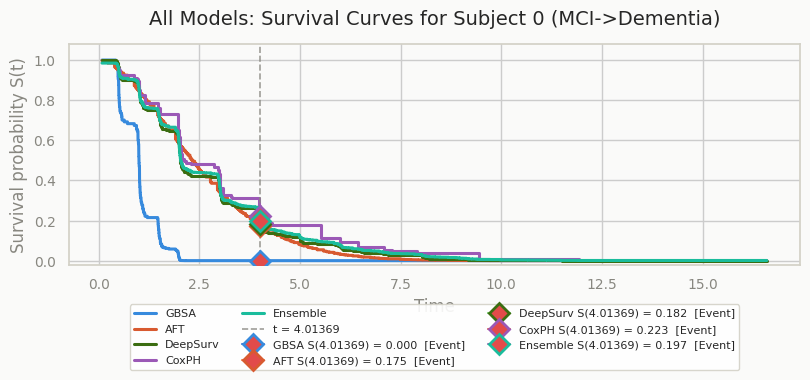

In [ ]:
i = 26
plot_individual_survival_curves(
    curves=[
        surv_gbsa_mci.iloc[:, i],
        aft_surv_mci.iloc[:, i],
        surv_mci.iloc[:, i],
        surv_cox_mci.iloc[:, i],
        ens_scores_mci.iloc[:, i],
    ],
    duration=float(y_dur_mci_test.iloc[i] if hasattr(y_dur_mci_test, 'iloc') else y_dur_mci_test[i]),
    event=int(y_ev_mci_test[i]),
    labels=[
        'GBSA',
        'AFT',
        'DeepSurv',
        'CoxPH',
        'Ensemble',
    ],
    title='All Models: Survival Curves for Subject 0 (MCI->AD)')
plt.savefig(FIG_DIR / 'all_models_survival_curves_subject0.png', dpi=150, bbox_inches='tight')

## 7. Final Results

All metrics are computed on the **held-out 20% test set**, withheld from all
training, cross-validation, and hyperparameter selection.

Bootstrap 95% CIs use 500 resamples (subjects sampled with replacement, no model
refit). Overlapping CIs between two models means their performance difference is
not statistically distinguishable at this test-set size.

KM risk-quartile plots and feature importance charts were shown inline after
each model above.



FINAL MODEL COMPARISON TABLE
            Model        Cohort   C-td
            CoxPH   CN->Decline 0.7712
             GBSA   CN->Decline 0.7408
         DeepSurv MCI->Dementia 0.8480
              AFT MCI->Dementia 0.8471
            CoxPH MCI->Dementia 0.8451
Weighted Ensemble MCI->Dementia 0.8414
             GBSA MCI->Dementia 0.8340

Saved: /content/alzheimer-prediction/Modeling on the Tabular dataset/outputs/model_comparison.csv


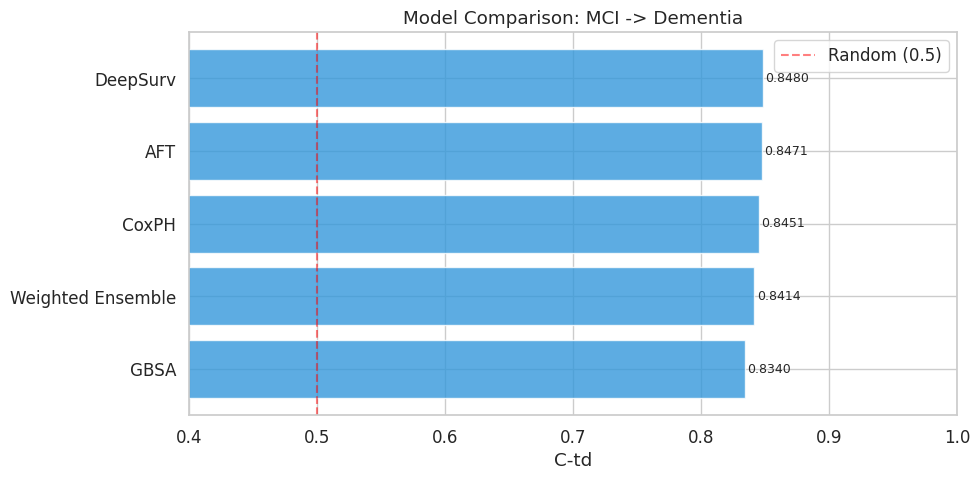

In [ ]:
rows = []
for (model, cohort), metrics in results.items():
    c_pt  = metrics[0]
    ci_lo = metrics[1] if len(metrics) > 1 else float('nan')
    ci_hi = metrics[2] if len(metrics) > 2 else float('nan')
    rows.append({
        'Model':    model,
        'Cohort':   cohort,
        'C-td':     f'{c_pt:.4f}',
        '95% CI':   f'[{ci_lo:.4f}, {ci_hi:.4f}]',
        'CI Width': f'{ci_hi - ci_lo:.4f}',
    })

results_df = pd.DataFrame(rows).sort_values(['Cohort', 'C-td'], ascending=[True, False])
print('\n' + '='*70)
print('FINAL MODEL COMPARISON -- MCI -> AD (held-out 20% test set)')
print('='*70)
print(results_df.to_string(index=False))
results_df.to_csv(OUT_DIR / 'model_comparison.csv', index=False)
print(f'\nSaved: {OUT_DIR}/model_comparison.csv')

mci_res = results_df[results_df['Cohort'].str.contains('MCI')].copy()
mci_res['c_float'] = mci_res['C-td'].astype(float)
mci_res['lo'] = mci_res['95% CI'].str.extract(r'\[([0-9.]+)').astype(float)
mci_res['hi'] = mci_res['95% CI'].str.extract(r', ([0-9.]+)\]').astype(float)
mci_res = mci_res.sort_values('c_float')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mci_res['Model'], mci_res['c_float'],
               color='#3498db', alpha=0.75, edgecolor='white', height=0.55)
xerr_lo = (mci_res['c_float'] - mci_res['lo']).values
xerr_hi = (mci_res['hi'] - mci_res['c_float']).values
ax.errorbar(mci_res['c_float'], mci_res['Model'],
            xerr=[xerr_lo, xerr_hi], fmt='none',
            color='#2c3e50', capsize=4, lw=2, label='95% bootstrap CI')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set(xlabel='C-td (IPCW Antolini)', title='Model Comparison: MCI -> AD', xlim=(0.4, 1.0))
for bar, val in zip(bars, mci_res['c_float']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
